# Traffic Demand Prediction Notebook

## Modeling story and final approach

This notebook follows the full path I used to build the final submission. I started with a simple inspection of the files, then used the patterns in the training data to decide which features were worth keeping and which ones were likely to overfit.

The main finding is that this is not a normal independent-row regression problem. The data is arranged by geohash, day, and 15-minute timestamp, so demand behaves like a location-time traffic curve. Because of that, the final model focuses on three things: location, road type, and the relationship between day 48 and the known early part of day 49.

The journey is:

1. **Understand the files.** Load `train.csv`, `test.csv`, and `sample_submission.csv`; check shapes, columns, missing values, and train-test consistency.
2. **Study missing values.** `RoadType`, `Temperature`, and `Weather` have missing values. `RoadType` is important, so I handle it carefully instead of using a blind missing label.
3. **Analyze the target.** Demand is very skewed: most rows are low demand, but a small group of road/location/time combinations can become much higher. This means the model must capture the high-demand tail without increasing all predictions blindly.
4. **Study road and location behavior.** `RoadType` explains broad demand levels, while `geohash` explains local differences. Interactions like `RoadType_hour`, `geo_hour`, and `geo_timestamp` are therefore natural features.
5. **Use day-48 as the historical anchor.** The complete day-48 curve is the strongest available reference, so I add same-slot day-48 demand for matching geohash and timestamp.
6. **Use the known early part of day 49 for calibration.** The early labeled rows of day 49 show how each geohash started relative to day 48. I convert this into summary and residual features.
7. **Avoid features that looked too good only in random KFold.** High-cardinality target encodings improved local CV, but they did not behave as reliably for submission. The final model keeps simpler, more explainable features.
8. **Train CatBoost and save correction scales.** CatBoost handles mixed categorical and numerical traffic features well. The final cell trains one 5-fold model and saves several submission files with different residual-correction strengths.

All modeling decisions below come from the competition train/test files only.

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    HAS_PLOTS = True
    sns.set_theme(style="whitegrid")
except Exception as exc:
    HAS_PLOTS = False
    print(f"Plotting libraries are not available in this environment: {exc}")


def show(obj):
    """Display nicely inside notebooks, fall back to print in plain Python."""
    try:
        display(obj)
    except NameError:
        print(obj)

DATA_DIR = Path("dataset")
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
SUBMISSION_PATH = DATA_DIR / "sample_submission.csv"

for path in [TRAIN_PATH, TEST_PATH, SUBMISSION_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Missing expected file: {path.resolve()}")


In [3]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SUBMISSION_PATH)

print("train:", train.shape)
print("test:", test.shape)
print("sample_submission:", sample_submission.shape)
show(train.head())
show(test.head())
show(sample_submission.head())


train: (77299, 11)
test: (41778, 10)
sample_submission: (5, 2)


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,49,2:15,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02z9,49,2:15,Residential,1,Not Allowed,No,6.476213,Snowy
2,2,qp02yf,49,2:15,Residential,3,Allowed,Yes,22.318203,Sunny
3,3,qp02z6,49,2:15,Residential,2,Not Allowed,Yes,NaN,Rainy
4,4,qp02zd,49,2:15,Residential,1,Not Allowed,No,18.266162,Foggy


,Index,demand
0,0,0.090768
1,1,0.089885
2,2,0.007037
3,3,0.079087
4,4,0.054636


## 1. File-Level Overview



In [4]:
def file_overview(frames):
    rows = []
    for name, df in frames.items():
        rows.append({
            "file": name,
            "rows": len(df),
            "columns": df.shape[1],
            "duplicate_rows": int(df.duplicated().sum()),
            "memory_mb": df.memory_usage(deep=True).sum() / (1024 ** 2),
        })
    return pd.DataFrame(rows)

frames = {
    "train.csv": train,
    "test.csv": test,
    "sample_submission.csv": sample_submission,
}
show(file_overview(frames))


,file,rows,columns,duplicate_rows,memory_mb
0,train.csv,77299,11,0,30.921675
1,test.csv,41778,10,0,16.370193
2,sample_submission.csv,5,2,0,0.000202


In [5]:
def schema_table(df, name):
    return pd.DataFrame({
        "file": name,
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(4).values,
        "unique_values": [df[c].nunique(dropna=False) for c in df.columns],
    })

schema = pd.concat([
    schema_table(train, "train"),
    schema_table(test, "test"),
    schema_table(sample_submission, "sample_submission"),
], ignore_index=True)
show(schema)


,file,column,dtype,missing_count,missing_pct,unique_values
0,train,Index,int64,0,0.000000,77299
1,train,geohash,object,0,0.000000,1249
2,train,day,int64,0,0.000000,2
3,train,timestamp,object,0,0.000000,96
4,train,demand,float64,0,0.000000,76715
5,train,RoadType,object,600,0.776200,4
6,train,NumberofLanes,int64,0,0.000000,5
7,train,LargeVehicles,object,0,0.000000,2
8,train,Landmarks,object,0,0.000000,2
9,train,Temperature,float64,2495,3.227700,74805


In [6]:
train_only_cols = sorted(set(train.columns) - set(test.columns))
test_only_cols = sorted(set(test.columns) - set(train.columns))
common_cols = [c for c in train.columns if c in test.columns]

print("Columns only in train:", train_only_cols)
print("Columns only in test:", test_only_cols)
print("Common feature columns:", common_cols)


Columns only in train: ['demand']
Columns only in test: []
Common feature columns: ['Index', 'geohash', 'day', 'timestamp', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather']


## 2. Missing Values

Only RoadType, Temperature, and Weather contain missing values. Missing percentages are very similar between train and test


In [7]:
def missing_report(df, name):
    out = pd.DataFrame({
        "file": name,
        "column": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(4).values,
    })
    return out.sort_values(["missing_count", "column"], ascending=[False, True])

missing = pd.concat([
    missing_report(train, "train"),
    missing_report(test, "test"),
], ignore_index=True)
show(missing[missing["missing_count"] > 0])


,file,column,missing_count,missing_pct
0,train,Temperature,2495,3.227700
1,train,Weather,797,1.031100
2,train,RoadType,600,0.776200
11,test,Temperature,1349,3.229000
12,test,Weather,431,1.031600
13,test,RoadType,324,0.775500


In [8]:
# Missingness patterns across the three nullable fields.
nullable_cols = ["RoadType", "Temperature", "Weather"]
for name, df in [("train", train), ("test", test)]:
    print(f"\n{name} missingness patterns")
    pattern = df[nullable_cols].isna().value_counts().reset_index(name="rows")
    show(pattern)



train missingness patterns


,RoadType,Temperature,Weather,rows
0,False,False,False,73459
1,False,True,False,2450
2,False,False,True,765
3,True,False,False,574
4,False,True,True,25
5,True,True,False,19
6,True,False,True,6
7,True,True,True,1



test missingness patterns


,RoadType,Temperature,Weather,rows
0,False,False,False,39702
1,False,True,False,1325
2,False,False,True,414
3,True,False,False,310
4,False,True,True,13
5,True,True,False,10
6,True,False,True,3
7,True,True,True,1


In [9]:
train.groupby("geohash")["Temperature"].apply(lambda x: x.isna().mean())

geohash
qp02yc   0.083333
qp02yf   0.000000
qp02yy   0.000000
qp02yz   0.066667
qp02z1   0.030303
           ...   
qp0dn4   0.000000
qp0dn5   0.000000
qp0dnh   0.500000
qp0dnj   0.090909
qp0dnn   0.000000
Name: Temperature, Length: 1249, dtype: float64

In [10]:
train.groupby("day")["Temperature"].apply(lambda x: x.isna().mean())

day
48   0.032279
49   0.032266
Name: Temperature, dtype: float64

In [11]:
stats = train.groupby("geohash").agg(
    total_rows=("Temperature", "size"),
    missing_rate=("Temperature", lambda x: x.isna().mean())
)

stats.sort_values("missing_rate", ascending=False)

,total_rows,missing_rate
geohash,,
qp08bn,2,0.500000
qp0dnh,2,0.500000
qp0d0g,2,0.500000
qp09ck,2,0.500000
qp0943,3,0.333333
...,...,...
qp09kn,6,0.000000
qp09km,5,0.000000
qp06p7,86,0.000000


Missing values are independent here.  

## 3. Duplicate And Key Checks

There are no duplicate full rows. The combination `geohash`, `day`, `timestamp` is unique in both train and test, so it is a natural row-level key.


In [12]:
key_sets = [
    ["Index"],
    ["geohash", "day", "timestamp"],
    ["geohash", "timestamp"],
]

rows = []
for name, df in [("train", train), ("test", test)]:
    for keys in key_sets:
        rows.append({
            "file": name,
            "key": ", ".join(keys),
            "duplicate_count": int(df.duplicated(keys).sum()),
            "unique_keys": int(df.drop_duplicates(keys).shape[0]),
        })
show(pd.DataFrame(rows))


,file,key,duplicate_count,unique_keys
0,train,Index,0,77299
1,train,"geohash, day, timestamp",0,77299
2,train,"geohash, timestamp",6423,70876
3,test,Index,0,41778
4,test,"geohash, day, timestamp",0,41778
5,test,"geohash, timestamp",0,41778


Confirmed facts:
- Index is an ID,
- (geohash, day, timestamp) uniquely identifies observations.
- Same (geohash, timestamp) appears across multiple days in train.
- Temporal-location patterns likely exist.
- Future feature engineering should focus on:
- geohash
- time of day
- geohash × time interactions

In [13]:
train_keys = set(
    zip(train.geohash, train.timestamp)
)
test_keys = set(
    zip(test.geohash, test.timestamp)
)
overlap = len(
    train_keys & test_keys
)
coverage = overlap / len(test_keys)
coverage

0.8888888888888888

In [14]:
unseen = test[
    ~test.set_index(["geohash","timestamp"]).index.isin(
        train.set_index(["geohash","timestamp"]).index
    )
]

In [15]:
unseen["geohash"].nunique()

673

In [16]:
seen_geohashes = set(train["geohash"])
unseen_geohashes = set(unseen["geohash"])

len(unseen_geohashes - seen_geohashes)

10

In [17]:
test[test["geohash"].isin(unseen_geohashes - seen_geohashes)]

,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
819,819,qp0dn1,49,2:15,Residential,1,Not Allowed,No,27.889829,Sunny
1882,1882,qp091d,49,2:45,Residential,3,Allowed,Yes,20.161541,Sunny
6460,6460,qp091n,49,4:0,Residential,1,Not Allowed,No,30.069198,Sunny
9258,9258,qp091n,49,4:45,Residential,1,Not Allowed,No,14.940989,Foggy
10194,10194,qp091n,49,5:0,Residential,3,Allowed,Yes,27.108440,Sunny
10972,10972,qp08g4,49,5:15,Residential,2,Not Allowed,Yes,17.877271,Foggy
11056,11056,qp091d,49,5:15,Residential,1,Not Allowed,No,16.746954,Foggy
11906,11906,qp08ch,49,5:30,Residential,1,Not Allowed,No,17.601525,Foggy
12918,12918,qp09j5,49,5:45,Residential,1,Not Allowed,No,19.776384,Sunny
13738,13738,qp08g4,49,6:0,Residential,3,Allowed,Yes,18.444005,Foggy


Notice that all the rows in test having new geohashes have road type as residential so we can fall back to road type for new locations.

Spatial coverage
- Train and test share almost all geohashes.
- Only 10 test geohashes are unseen.
- Therefore location-based features should generalize well.

Temporal coverage
- 88.9% of location-time pairs have been observed before.
- Historical patterns are likely useful.

## 4. Target Analysis: `demand`

`demand` is a continuous target with a strong right skew. Most values are small, while 585 training records are exactly `1.0`. This suggests clipping or normalization at the upper bound.


In [18]:
target = "demand"
percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
show(train[target].describe(percentiles=percentiles).to_frame())

print("Rows with demand == 1.0:", int((train[target] == 1.0).sum()))
print("Rows with demand <= 0.001:", int((train[target] <= 0.001).sum()))
print("Rows with demand <= 0.01:", int((train[target] <= 0.01).sum()))
print("Rows with demand >= 0.5:", int((train[target] >= 0.5).sum()))


,demand
count,"77,299.000000"
mean,0.093942
std,0.142191
min,0.000001
1%,0.000625
5%,0.003172
10%,0.006422
25%,0.018227
50%,0.047760
75%,0.108595


Rows with demand == 1.0: 585
Rows with demand <= 0.001: 1254
Rows with demand <= 0.01: 11517
Rows with demand >= 0.5: 1941


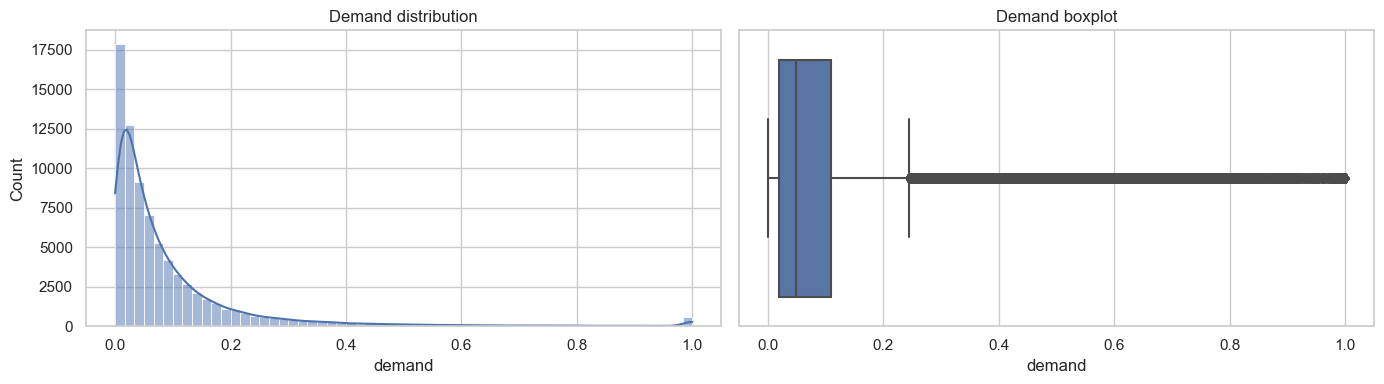

In [19]:
if HAS_PLOTS:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(train[target], bins=60, kde=True, ax=axes[0])
    axes[0].set_title("Demand distribution")
    sns.boxplot(x=train[target], ax=axes[1])
    axes[1].set_title("Demand boxplot")
    plt.tight_layout()
    plt.show()
else:
    print("Install matplotlib and seaborn to render plots in this notebook.")


Observation: Target Distribution

- Demand is strongly right-skewed, with most observations concentrated below 0.10.
- A long tail of high-demand observations extends toward the upper bound of 1.0.
- The median demand (~0.048) is substantially lower than the mean (~0.094), indicating the presence of a small number of high-demand observations.
- The target is bounded between 0 and 1 and exhibits significant non-normality.
- High-demand observations appear to be genuine patterns rather than data errors, as several geohashes consistently exhibit elevated demand levels.

In [20]:
train.groupby("RoadType")["demand"].describe()

,count,mean,std,min,25%,50%,75%,max
RoadType,,,,,,,,
Highway,"3,560.000000",0.610756,0.229419,0.350009,0.413629,0.526432,0.790095,1.000000
Residential,"69,230.000000",0.057209,0.052057,0.000001,0.016203,0.040517,0.084468,0.219997
Street,"3,909.000000",0.273164,0.036693,0.220016,0.240702,0.268124,0.301890,0.349908


RoadType Analysis
- Strong monotonic relationship with demand.
- Highway roads have ~10x higher average demand than residential roads.
- Quartile ranges show limited overlap.
- RoadType is expected to be one of the most important predictors.

In [21]:
train.groupby("Weather")["demand"].describe()

,count,mean,std,min,25%,50%,75%,max
Weather,,,,,,,,
Foggy,"20,243.000000",0.093372,0.141110,0.000006,0.018215,0.047571,0.108625,1.000000
Rainy,"20,824.000000",0.094471,0.141608,0.000001,0.018083,0.048467,0.110044,1.000000
Snowy,"7,718.000000",0.092581,0.138300,0.000004,0.018214,0.047775,0.108075,1.000000
Sunny,"27,717.000000",0.094247,0.144367,0.000001,0.018258,0.047230,0.107245,1.000000


Very less effect of weather on demand standalone

In [22]:
train.groupby("LargeVehicles")["demand"].describe()

,count,mean,std,min,25%,50%,75%,max
LargeVehicles,,,,,,,,
Allowed,"26,626.000000",0.131923,0.212567,0.000001,0.019261,0.051223,0.122294,1.000000
Not Allowed,"50,673.000000",0.073986,0.077097,0.000001,0.017699,0.046023,0.102839,0.349908


Not much info from large vehicles alone

In [23]:
pd.crosstab(
    train["RoadType"],
    train["LargeVehicles"]
)

LargeVehicles,Allowed,Not Allowed
RoadType,,
Highway,3560,0
Residential,22870,46360
Street,0,3909


In [24]:
train.groupby(
    ["RoadType", "LargeVehicles"]
)["demand"].describe()

count     mean      std      min      25%  \
RoadType    LargeVehicles                                                     
Highway     Allowed        3,560.000000 0.610756 0.229419 0.350009 0.413629   
Residential Allowed       22,870.000000 0.057253 0.052069 0.000001 0.016339   
            Not Allowed   46,360.000000 0.057188 0.052051 0.000001 0.016122   
Street      Not Allowed    3,909.000000 0.273164 0.036693 0.220016 0.240702   

                               50%      75%      max  
RoadType    LargeVehicles                             
Highway     Allowed       0.526432 0.790095 1.000000  
Residential Allowed       0.040625 0.084477 0.219945  
            Not Allowed   0.040464 0.084466 0.219997  
Street      Not Allowed   0.268124 0.301890 0.349908

Let's compare the Residential rows:

RoadType	LargeVehicles	Mean Demand
Residential	Allowed	0.057253
Residential	Not Allowed	0.057188

Difference:

0.057253 - 0.057188
= 0.000065

That's essentially zero.

This is a confounding variable

The true relationship is:

RoadType-> influences Demand ->determines LargeVehicles

So LargeVehicles looked predictive only because it was carrying information about RoadType.

Suspected behaviour of data

RoadType-> determines -> lanes -> large vehicles-> baseline demand

In [25]:
train.groupby("NumberofLanes")["demand"].describe()

,count,mean,std,min,25%,50%,75%,max
NumberofLanes,,,,,,,,
1,"27,411.000000",0.088104,0.090681,0.000004,0.019475,0.052204,0.126136,0.349908
2,"24,127.000000",0.077488,0.124543,0.000001,0.016800,0.043005,0.092359,1.000000
3,"23,919.000000",0.077859,0.125011,0.000001,0.017063,0.042845,0.092126,1.000000
4,926.000000,0.602882,0.225795,0.350226,0.412532,0.513090,0.780396,1.000000
5,916.000000,0.607556,0.226946,0.350009,0.413233,0.521678,0.779799,1.000000


In [26]:
pd.crosstab(
    train["RoadType"],
    train["NumberofLanes"]
)

NumberofLanes,1,2,3,4,5
RoadType,,,,,
Highway,0,855,881,915,909
Residential,23269,23091,22870,0,0
Street,3909,0,0,0,0


NumberofLanes

Strongly correlated with RoadType.

- Street always has 1 lane.
- Residential has 1–3 lanes.
- Highway has 2–5 lanes.

Therefore lane effects should be analyzed conditional on RoadType.

In [27]:
train.groupby(
    ["RoadType","NumberofLanes"]
)["demand"].describe()

count     mean      std      min      25%  \
RoadType    NumberofLanes                                                     
Highway     2                855.000000 0.619695 0.234357 0.350059 0.415655   
            3                881.000000 0.613320 0.230976 0.350553 0.413894   
            4                915.000000 0.603511 0.225790 0.350226 0.412598   
            5                909.000000 0.607156 0.226879 0.350009 0.413037   
Residential 1             23,269.000000 0.057050 0.051700 0.000004 0.016212   
            2             23,091.000000 0.057326 0.052403 0.000001 0.016052   
            3             22,870.000000 0.057253 0.052069 0.000001 0.016339   
Street      1              3,909.000000 0.273164 0.036693 0.220016 0.240702   

                               50%      75%      max  
RoadType    NumberofLanes                             
Highway     2             0.527272 0.824750 1.000000  
            3             0.537768 0.805432 1.000000  
            4             0.513536 0.780930 1.000000  
            5             0.522120 0.778972 1.000000  
Residential 1             0.040378 0.084436 0.219979  
            2             0.040539 0.084474 0.219997  
            3             0.040625 0.084477 0.219945  
Street      1             0.268124 0.301890 0.349908

RoadType carries most of the signal.

NumberofLanes carries mostly redundant signal.

RoadType- Very strong predictor.

NumberofLanes- Highly correlated with RoadType.

Conditional analysis shows almost no change in demand within the same RoadType.

Therefore:

- NumberofLanes is unlikely to be a top standalone predictor.
- Most of its predictive power is already captured by RoadType.



In [28]:
train.groupby("Landmarks")["demand"].describe()

,count,mean,std,min,25%,50%,75%,max
Landmarks,,,,,,,,
No,"25,257.000000",0.096295,0.162751,0.000004,0.017723,0.045579,0.100368,1.000000
Yes,"52,042.000000",0.092801,0.131041,0.000001,0.018476,0.048974,0.112958,1.000000


the mean difference is not much. But the median and and 75th quartile is higher for "Yes" yet the mean is low. This means data is skewed with some very high demand rows in "No" landmark

In [29]:
train.groupby(
    ["RoadType", "Landmarks"]
)["demand"].describe()

count     mean      std      min      25%  \
RoadType    Landmarks                                                     
Highway     No         1,764.000000 0.613234 0.230553 0.350009 0.413615   
            Yes        1,796.000000 0.608323 0.228338 0.350226 0.413744   
Residential No        23,269.000000 0.057050 0.051700 0.000004 0.016212   
            Yes       45,961.000000 0.057290 0.052237 0.000001 0.016190   
Street      Yes        3,909.000000 0.273164 0.036693 0.220016 0.240702   

                           50%      75%      max  
RoadType    Landmarks                             
Highway     No        0.525526 0.799485 1.000000  
            Yes       0.527772 0.784303 1.000000  
Residential No        0.040378 0.084436 0.219979  
            Yes       0.040597 0.084476 0.219997  
Street      Yes       0.268124 0.301890 0.349908

Observation: Landmarks vs Demand

- The presence of landmarks does not show a strong relationship with traffic demand.
- Overall mean demand is very similar for roads with landmarks (0.0928) and without landmarks (0.0963).
- When analyzed within each RoadType, the differences become even smaller:
- Highway: Landmark = No (0.6132) vs Yes (0.6083)
- Residential: Landmark = No (0.0571) vs Yes (0.0573)

This indicates that the apparent variation in demand is largely explained by RoadType rather than the presence of landmarks.

Additionally, all Street roads are associated with landmarks, suggesting a dependency between the two features.

Therefore, Landmarks appears to have limited standalone predictive power and may be redundant with RoadType and other location-related features.



## 5. Time Coverage

The train/test split is time-based:

| Dataset Slice | Coverage |
|---|---|
| Train day 48 | Full day, 96 quarter-hour timestamps from `0:0` to `23:45` |
| Train day 49 | First 9 timestamps from `0:0` to `2:0` |
| Test day 49 | Next 47 timestamps from `2:15` to `13:45` |

This makes time features and location history important.


In [30]:
def timestamp_to_minutes(series):
    parts = series.astype(str).str.split(":", expand=True).astype(int)
    return parts[0] * 60 + parts[1]


def add_time_features(df):
    out = df.copy()
    parts = out["timestamp"].astype(str).str.split(":", expand=True).astype(int)
    out["hour"] = parts[0]
    out["minute_of_hour"] = parts[1]
    out["minute"] = out["hour"] * 60 + out["minute_of_hour"]
    out["quarter_hour_index"] = out["minute"] // 15
    return out

train_time = add_time_features(train)
test_time = add_time_features(test)

coverage_rows = []
for name, df in [("train", train_time), ("test", test_time)]:
    for day, g in df.groupby("day"):
        coverage_rows.append({
            "file": name,
            "day": day,
            "rows": len(g),
            "unique_geohashes": g["geohash"].nunique(),
            "unique_timestamps": g["timestamp"].nunique(),
            "first_timestamp": g.sort_values("minute")["timestamp"].iloc[0],
            "last_timestamp": g.sort_values("minute")["timestamp"].iloc[-1],
        })
show(pd.DataFrame(coverage_rows))


,file,day,rows,unique_geohashes,unique_timestamps,first_timestamp,last_timestamp
0,train,48,69427,1241,96,0:0,23:45
1,train,49,7872,1078,9,0:0,2:0
2,test,49,41778,1190,47,2:15,13:45


In [31]:
# Counts per timestamp, useful for checking sparse coverage.
for name, df in [("train", train_time), ("test", test_time)]:
    counts = (
        df.groupby(["day", "timestamp", "minute"])
          .size()
          .reset_index(name="rows")
          .sort_values(["day", "minute"])
    )
    print(f"\n{name}: first 12 timestamp counts")
    show(counts.head(12))
    print(f"\n{name}: last 12 timestamp counts")
    show(counts.tail(12))



train: first 12 timestamp counts


,day,timestamp,minute,rows
0,48,0:0,0,692
1,48,0:15,15,714
2,48,0:30,30,747
3,48,0:45,45,758
44,48,1:0,60,800
45,48,1:15,75,818
46,48,1:30,90,851
47,48,1:45,105,859
64,48,2:0,120,876
65,48,2:15,135,895



train: last 12 timestamp counts


,day,timestamp,minute,rows
61,48,23:15,1395,764
62,48,23:30,1410,772
63,48,23:45,1425,805
96,49,0:0,0,842
97,49,0:15,15,864
98,49,0:30,30,870
99,49,0:45,45,851
100,49,1:0,60,868
101,49,1:15,75,880
102,49,1:30,90,899



test: first 12 timestamp counts


,day,timestamp,minute,rows
16,49,2:15,135,887
17,49,2:30,150,915
18,49,2:45,165,896
19,49,3:0,180,897
20,49,3:15,195,896
21,49,3:30,210,908
22,49,3:45,225,909
23,49,4:0,240,928
24,49,4:15,255,926
25,49,4:30,270,939



test: last 12 timestamp counts


,day,timestamp,minute,rows
4,49,11:0,660,897
5,49,11:15,675,870
6,49,11:30,690,876
7,49,11:45,705,871
8,49,12:0,720,878
9,49,12:15,735,856
10,49,12:30,750,847
11,49,12:45,765,834
12,49,13:0,780,815
13,49,13:15,795,805


,day,timestamp,minute,rows,mean_demand,median_demand
0,48,0:0,0,692,0.052978,0.031396
1,48,0:15,15,714,0.055620,0.031205
2,48,0:30,30,747,0.059129,0.034614
3,48,0:45,45,758,0.061757,0.035475
44,48,1:0,60,800,0.066018,0.038737
45,48,1:15,75,818,0.071537,0.042542
46,48,1:30,90,851,0.074469,0.044974
47,48,1:45,105,859,0.078032,0.043007
64,48,2:0,120,876,0.082184,0.048262
65,48,2:15,135,895,0.082506,0.045687


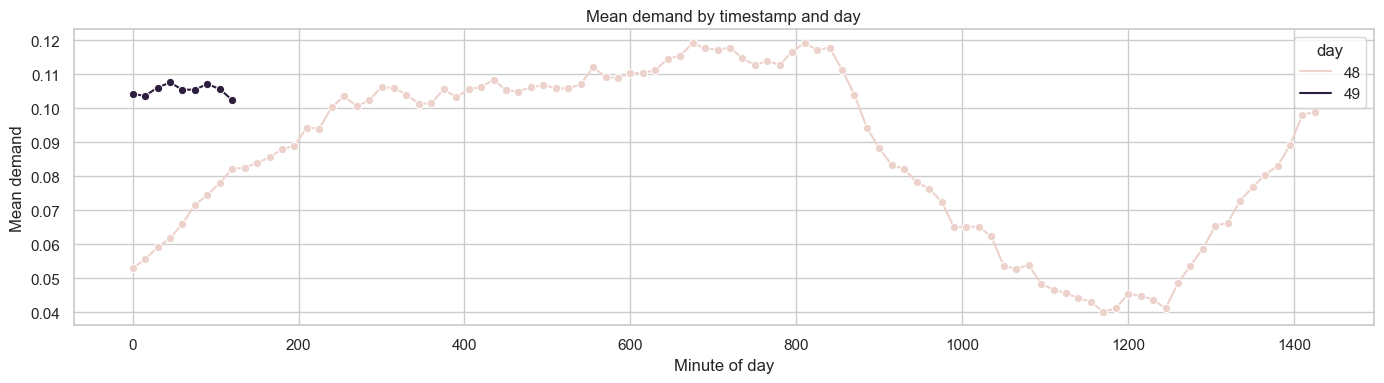

In [32]:
# Mean demand by time bucket in train.
time_target = (
    train_time.groupby(["day", "timestamp", "minute"], as_index=False)[target]
    .agg(rows="count", mean_demand="mean", median_demand="median")
    .sort_values(["day", "minute"])
)
show(time_target.head(20))

if HAS_PLOTS:
    plt.figure(figsize=(14, 4))
    sns.lineplot(data=time_target, x="minute", y="mean_demand", hue="day", marker="o")
    plt.title("Mean demand by timestamp and day")
    plt.xlabel("Minute of day")
    plt.ylabel("Mean demand")
    plt.tight_layout()
    plt.show()


In [33]:
train["hour"] = train["timestamp"].str.split(":").str[0].astype(int)

train["minute"] = train["timestamp"].str.split(":").str[1].astype(int)

In [34]:
hour_stats = (
    train.groupby("hour")["demand"]
         .agg(["count","mean","median"])
)
hour_stats

,count,mean,median
hour,,,
0,6338,0.083369,0.043276
1,6871,0.089793,0.048514
2,4455,0.087368,0.049285
3,3595,0.091329,0.051589
4,3683,0.101678,0.056901
5,3621,0.104368,0.058598
6,3665,0.103913,0.057304
7,3569,0.106198,0.057081
8,3507,0.106149,0.055932


<Axes: xlabel='hour'>

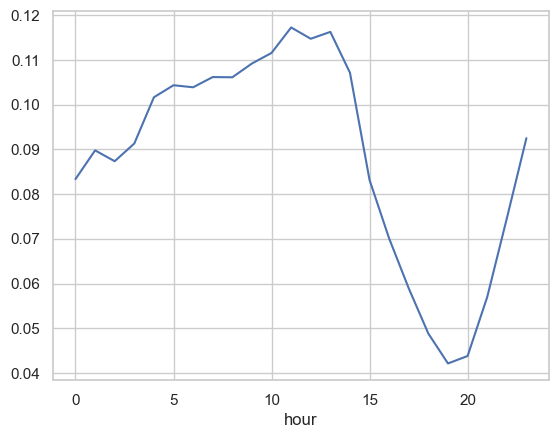

In [35]:
hour_stats["mean"].plot()

This is NOT the classic commuting pattern.

A typical traffic dataset would look like:

Morning peak-> Midday dip->Evening peak

But this looks more like:

- Early morning: low
- Late morning: high
- Afternoon: decline
- Evening: lowest
- Night: recovery

It may imply that:

- demand may not be pure traffic volume
- demand may be some normalized utilization metric

Observation: Hour of Day vs Demand

- Demand exhibits a strong temporal pattern throughout the day.
- Average demand increases steadily from midnight to late morning.
- Peak demand occurs around 11:00–13:00, with average values near 0.116–0.117.
- Demand then declines throughout the afternoon and reaches its minimum around 19:00 (0.042).
- After 19:00, demand gradually increases again during the late evening hours.
- The variation across hours is substantially larger than the variation observed for Temperature or Weather.

Modeling Implication

- Hour of day is likely a strong predictor of demand.

Timestamp-derived features should be included in the model:
- hour
- minute
- quarter-hour
- cyclic encoding (sin/cos hour)
- Temporal features are expected to contribute more predictive power than Temperature or Weather.

## 6. Geohash Coverage

Train contains 1,249 unique geohashes. Test contains 1,190 unique geohashes. Of the test geohashes, 1,180 are also present in train, so 99.16% of test locations have historical training data. There are 10 geohashes that appear only in test.


In [36]:
train_geo = set(train["geohash"])
test_geo = set(test["geohash"])

geo_summary = pd.DataFrame([
    {"metric": "unique train geohashes", "value": len(train_geo)},
    {"metric": "unique test geohashes", "value": len(test_geo)},
    {"metric": "geohashes in both", "value": len(train_geo & test_geo)},
    {"metric": "geohashes only in train", "value": len(train_geo - test_geo)},
    {"metric": "geohashes only in test", "value": len(test_geo - train_geo)},
    {"metric": "test geohash coverage pct", "value": round(len(train_geo & test_geo) / len(test_geo) * 100, 2)},
])
show(geo_summary)

print("Test-only geohashes:")
print(sorted(test_geo - train_geo))


,metric,value
0,unique train geohashes,"1,249.000000"
1,unique test geohashes,"1,190.000000"
2,geohashes in both,"1,180.000000"
3,geohashes only in train,69.000000
4,geohashes only in test,10.000000
5,test geohash coverage pct,99.160000


Test-only geohashes:
['qp08ch', 'qp08g4', 'qp091d', 'qp091n', 'qp0965', 'qp09j5', 'qp09tv', 'qp09vh', 'qp09y0', 'qp0dn1']


In [37]:
for name, df in [("train", train), ("test", test)]:
    print(f"\n{name}: top geohashes by row count")
    show(df["geohash"].value_counts().head(15).to_frame("rows"))



train: top geohashes by row count


,rows
geohash,
qp03xk,105
qp092r,105
qp03wz,105
qp03xp,105
qp097y,105
qp03r0,105
qp03r2,105
qp03xx,105
qp096y,105



test: top geohashes by row count


,rows
geohash,
qp09dp,47
qp098e,47
qp099g,47
qp09d5,47
qp09d7,47
qp09de,47
qp09dg,47
qp09e5,47
qp09e7,47


In [38]:
geo_stats = (
    train.groupby("geohash")["demand"]
         .agg(["count","mean","median","std"])
)

geo_stats["mean"].describe()

count   1,249.000000
mean        0.064671
std         0.099861
min         0.000495
25%         0.012661
50%         0.030807
75%         0.075227
max         0.960715
Name: mean, dtype: float64

In [39]:
geo_stats.sort_values("mean", ascending=False).head(10)

,count,mean,median,std
geohash,,,,
qp09d9,105,0.960715,1.000000,0.090041
qp09ft,105,0.868850,1.000000,0.209092
qp09e5,105,0.864989,1.000000,0.239612
qp09d8,105,0.669318,0.733929,0.234383
qp096x,105,0.665630,0.771472,0.296666
qp09d2,105,0.664722,0.696835,0.334164
qp09dc,105,0.661462,0.821493,0.368198
qp096r,105,0.650468,0.659369,0.344110
qp09d3,105,0.643498,0.685006,0.295267


In [40]:
pair_stats = (
    train.groupby(
        ["geohash", "timestamp"]
    )["demand"]
    .agg(["count", "mean", "std"])
)

pair_stats["count"].describe()
pair_stats["std"].describe()

count   6,423.000000
mean        0.044968
std         0.063056
min         0.000000
25%         0.009829
50%         0.024837
75%         0.054411
max         0.591134
Name: std, dtype: float64

Observation: Geohash × Timestamp Stability

- Demand exhibits relatively low variability for the same (geohash, timestamp) combination.
- The median standard deviation across combinations is 0.025, indicating that demand is generally stable for a fixed location and time.
- 75% of combinations have a standard deviation below 0.054.
- This suggests that historical demand patterns repeat consistently across observations.
- Combined with the high train-test overlap of (geohash, timestamp) pairs (~88.9%), these patterns are likely to be highly predictive.

Modeling Implication

The following aggregated features are likely to be among the strongest predictors:

- geohash_mean_demand
- timestamp_mean_demand
- geohash_timestamp_mean_demand

In [42]:
pivot = train.pivot_table(
    values="demand",
    index="hour",
    columns="RoadType",
    aggfunc="mean"
)

pivot

RoadType,Highway,Residential,Street
hour,,,
0,0.561809,0.054520,0.273934
1,0.565261,0.058194,0.274616
2,0.559365,0.059609,0.272234
3,0.568663,0.059994,0.264126
4,0.586614,0.062093,0.269013
5,0.605216,0.062546,0.272907
6,0.617390,0.062551,0.272421
7,0.636852,0.063589,0.279034
8,0.632307,0.062966,0.277388


Observation: Hour × RoadType Interaction

Demand patterns vary significantly across RoadTypes.

Residential roads show a strong daily cycle:
- Peak demand around 11:00–13:00.
- Lowest demand around 18:00–20:00.

Highway roads exhibit a different pattern:
- Demand remains high throughout the day.
- Peak demand occurs around 18:00.

Street roads show relatively stable demand with minimal hourly variation.

These findings indicate a strong interaction between RoadType and Time.



In [43]:
train.groupby("geohash")["RoadType"].nunique()

geohash
qp02yc    1
qp02yf    1
qp02yy    1
qp02yz    1
qp02z1    1
         ..
qp0dn4    1
qp0dn5    1
qp0dnh    1
qp0dnj    1
qp0dnn    1
Name: RoadType, Length: 1249, dtype: int64

In [45]:
heat = train.pivot_table(
    values="demand",
    index="geohash",
    columns="hour",
    aggfunc="mean"
)
heat

hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
geohash,,,,,,,,,,,,,,,,,,,,,,,,
qp02yc,NaN,0.005397,0.019452,0.026422,NaN,NaN,0.014584,0.012256,NaN,0.017362,0.033974,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
qp02yf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.029433,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
qp02yy,NaN,NaN,NaN,NaN,0.003916,NaN,NaN,NaN,0.001887,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
qp02yz,NaN,NaN,0.016283,0.011198,0.023444,0.043532,0.056422,0.028653,0.028768,0.017931,0.056320,0.028281,0.025485,NaN,NaN,0.050364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
qp02z1,0.034855,0.064814,0.060869,0.045585,0.009996,0.020028,0.008734,NaN,0.019275,NaN,NaN,NaN,0.057574,0.001217,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
qp0dn4,NaN,0.000800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.011316,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
qp0dn5,NaN,NaN,NaN,0.001070,NaN,NaN,0.005265,0.004382,NaN,0.001943,0.004371,0.003701,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
qp0dnh,NaN,NaN,0.000366,NaN,0.002437,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
train.groupby(["geohash","hour"]).size().describe()

count   21,089.000000
mean         3.665371
std          1.537954
min          1.000000
25%          3.000000
50%          4.000000
75%          4.000000
max          8.000000
dtype: float64

In [47]:
train.groupby("geohash")["hour"].nunique().describe()

count   1,249.000000
mean       16.884708
std         7.259797
min         1.000000
25%        13.000000
50%        19.000000
75%        23.000000
max        24.000000
Name: hour, dtype: float64

Let's combine all discoveries:

Geohash
- Completely determines RoadType.
- Strongly determines average demand.

Hour
- Strong temporal effect.
- Different effect by RoadType.

Geohash × Hour
- Repeated multiple times.
- Fairly stable (median std ≈ 0.025).
- Large train-test overlap (~89%).

In [48]:
train.groupby(
    ["geohash","timestamp"]
)["demand"].agg(
    ["mean","std","count"]
)

mean  std  count
geohash timestamp                     
qp02yc  10:30     0.046790  NaN      1
        10:45     0.021158  NaN      1
        1:0       0.005397  NaN      1
        2:30      0.012944  NaN      1
        2:45      0.025961  NaN      1
...                    ...  ...    ...
qp0dnj  9:0       0.023207  NaN      1
        9:15      0.028085  NaN      1
        9:30      0.049272  NaN      1
qp0dnn  19:45     0.007751  NaN      1
        4:30      0.000738  NaN      1

[70876 rows x 3 columns]

In [49]:
train.groupby(
    ["geohash","hour"]
)["demand"].mean()

geohash  hour
qp02yc   1      0.005397
         2      0.019452
         3      0.026422
         6      0.014584
         7      0.012256
                  ...   
qp0dnj   13     0.010766
         22     0.012757
         23     0.006790
qp0dnn   4      0.000738
         19     0.007751
Name: demand, Length: 21089, dtype: float64

In [50]:
train.groupby(
    ["geohash", "hour"]
)["demand"].agg(
    ["count","mean","std"]
)

count     mean      std
geohash hour                         
qp02yc  1         1 0.005397      NaN
        2         2 0.019452 0.009204
        3         1 0.026422      NaN
        6         2 0.014584 0.008763
        7         3 0.012256 0.012848
...             ...      ...      ...
qp0dnj  13        1 0.010766      NaN
        22        1 0.012757      NaN
        23        3 0.006790 0.008153
qp0dnn  4         1 0.000738      NaN
        19        1 0.007751      NaN

[21089 rows x 3 columns]

## 7. Categorical Feature Distributions

All non-null categorical levels in test are already seen in train. Missing values still need explicit handling.


In [16]:
cat_cols = ["RoadType", "NumberofLanes", "LargeVehicles", "Landmarks", "Weather", "day"]

for col in cat_cols:
    if col not in train.columns or col not in test.columns:
        continue
    train_counts = train[col].value_counts(dropna=False).rename("train_count")
    test_counts = test[col].value_counts(dropna=False).rename("test_count")
    counts = pd.concat([train_counts, test_counts], axis=1).fillna(0).astype(int)
    counts["train_pct"] = counts["train_count"] / len(train) * 100
    counts["test_pct"] = counts["test_count"] / len(test) * 100
    print(f"\n{col}")
    show(counts.sort_values("train_count", ascending=False))



RoadType


,train_count,test_count,train_pct,test_pct
RoadType,,,,
Residential,69230,33775,89.561314,80.843985
Street,3909,3407,5.056987,8.155010
Highway,3560,4272,4.605493,10.225478
NaN,600,324,0.776207,0.775528



NumberofLanes


,train_count,test_count,train_pct,test_pct
NumberofLanes,,,,
1,27411,14828,35.461002,35.492364
2,24127,12422,31.212564,29.733352
3,23919,12406,30.943479,29.695055
4,926,1062,1.197946,2.542008
5,916,1060,1.185009,2.537221



LargeVehicles


...

,train_count,test_count,train_pct,test_pct
Landmarks,,,,
Yes,52042,28245,67.325580,67.607353
No,25257,13533,32.674420,32.392647



Weather


,train_count,test_count,train_pct,test_pct
Weather,,,,
Sunny,27717,15078,35.856867,36.090765
Rainy,20824,11081,26.939546,26.523529
Foggy,20243,11102,26.187920,26.573795
Snowy,7718,4086,9.984605,9.780267
NaN,797,431,1.031061,1.031643



day


,train_count,test_count,train_pct,test_pct
day,,,,
48,69427,0,89.816168,0.000000
49,7872,41778,10.183832,100.000000


As we know, Road type is most valuable here, and residential type appears in most of the data, lets lookk into it more.
Also we must notice that no. of highways increase significantly in test dataset. (almost double than train dtaset), thus there is a distribution shift (though very slight).

In [46]:
train[train["RoadType"].isna()]

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
129,129,qp0970,48,0:0,0.035033,NaN,2,Not Allowed,Yes,20.468298,Sunny
258,258,qp097y,48,0:0,0.109629,NaN,1,Not Allowed,No,20.213439,Sunny
387,387,qp03wk,48,0:0,0.011208,NaN,3,Allowed,Yes,5.300437,Snowy
516,516,qp03yd,48,0:0,0.064833,NaN,1,Not Allowed,No,15.053470,Foggy
...,...,...,...,...,...,...,...,...,...,...,...
76755,76755,qp096z,49,2:0,0.324232,NaN,1,Not Allowed,Yes,15.408261,Foggy
76884,76884,qp03tu,49,2:0,0.038666,NaN,3,Allowed,Yes,13.211781,Rainy
77013,77013,qp09g0,49,2:0,0.051121,NaN,1,Not Allowed,No,18.688193,Foggy
77142,77142,qp09uv,49,2:0,0.373182,NaN,3,Allowed,Yes,11.304083,Rainy


The missing group is much closer to Residential than to Street or Highway

In [47]:
train[train["RoadType"].isna()]["timestamp"].value_counts().sort_index()

timestamp
0:0      12
0:15     12
0:30     13
0:45     12
10:0      7
10:15     7
10:30     7
10:45     7
11:0      7
11:15     7
11:30     6
11:45     7
12:0      7
12:15     7
12:30     7
12:45     7
13:0      6
13:15     7
13:30     6
13:45     6
14:0      6
14:15     6
14:30     6
14:45     5
15:0      6
15:15     5
15:30     5
15:45     4
16:0      5
16:15     4
16:30     4
16:45     4
17:0      3
17:15     4
17:30     3
17:45     3
18:0      2
18:15     3
18:30     2
18:45     2
19:0      3
19:15     2
19:30     2
19:45     3
1:0      13
1:15     14
1:30     13
1:45     14
20:0      3
20:15     2
20:30     3
20:45     3
21:0      3
21:15     3
21:30     4
21:45     3
22:0      4
22:15     5
22:30     5
22:45     5
23:0      6
23:15     5
23:30     6
23:45     7
2:0      14
2:15      7
2:30      7
2:45      6
3:0       7
3:15      7
3:30      7
3:45      7
4:0       7
4:15      7
4:30      8
4:45      7
5:0       7
5:15      7
5:30      7
5:45      7
6:0       7
6:15      7
6:30  

In [48]:
pd.crosstab(
    train["RoadType"].fillna("Missing"),
    train["LargeVehicles"]
)

LargeVehicles,Allowed,Not Allowed
RoadType,,
Highway,3560,0
Missing,196,404
Residential,22870,46360
Street,0,3909


In [49]:
pd.crosstab(
    train["RoadType"].fillna("Missing"),
    train["Landmarks"]
)

Landmarks,No,Yes
RoadType,,
Highway,1764,1796
Missing,224,376
Residential,23269,45961
Street,0,3909


In [50]:
train[train["RoadType"].isna()]\
.groupby(["NumberofLanes","LargeVehicles"])\
.size()

NumberofLanes  LargeVehicles
1              Not Allowed      233
2              Allowed           10
               Not Allowed      171
3              Allowed          168
4              Allowed           11
5              Allowed            7
dtype: int64

LargeVehicles
- RoadType |	Allowed %
- Highway |	100%
- Residential |	33%
- Street |	0%
- Missing	196/600 = 32.7%

The missing group is almost identical to Residential.

Observation: Missing RoadType Values

- Missing RoadType records account for only 0.78% of the training data.
- Analysis of related road attributes suggests that these records closely resemble Residential roads.
- The distribution of LargeVehicles permissions is nearly identical:
- Residential: ~33% Allowed, ~67% Not Allowed
- Missing: ~33% Allowed, ~67% Not Allowed

Landmark distribution is also very similar:
- Residential: ~66% Yes
- Missing: ~63% Yes
- No strong temporal concentration was observed; missing values occur throughout the day.
- These findings suggest that missing RoadType values are likely due to incomplete data collection rather than representing a distinct road category.

Modeling Implication
Imputing missing RoadType values as "Unknown" is acceptable.
Alternatively, imputing them as "Residential" may also be reasonable given the observed feature distributions.
Because the affected rows represent less than 1% of the dataset, the impact on overall model performance is expected to be minimal.

In [51]:
pd.crosstab(
    [train["NumberofLanes"],
     train["LargeVehicles"],
     train["Landmarks"]],
    train["RoadType"]
)

RoadType                               Highway  Residential  Street
NumberofLanes LargeVehicles Landmarks                              
1             Not Allowed   No               0        23269       0
                            Yes              0            0    3909
2             Allowed       No             855            0       0
              Not Allowed   Yes              0        23091       0
3             Allowed       Yes            881        22870       0
4             Allowed       Yes            915            0       0
5             Allowed       No             909            0       0

Observation: RoadType Recoverability

RoadType is highly dependent on NumberofLanes, LargeVehicles, and Landmarks.

- Six of seven observed feature combinations uniquely determine the RoadType.
- The only ambiguous combination (3 lanes, LargeVehicles Allowed, Landmark Yes) corresponds to Residential roads in approximately 96% of cases.
- Therefore, RoadType can be accurately inferred from the remaining road attributes.
- Missing RoadType values can be imputed using deterministic rules with high confidence.

Only one ambiguous combination
(3, Allowed, Yes)

appears in:

- Highway   -   881 rows
- Residential - 22870 rows

So:

P(Residential ∣ 3,Allowed,Yes)=
22870/(22870+881)​

≈96.3%

Only:

P(Highway∣3,Allowed,Yes)≈3.7%

Since RoadType is one of the strongest predictors of demand and can be inferred with high confidence from NumberofLanes, LargeVehicles, and Landmarks, missing RoadType values were imputed using rule-based logic derived from observed feature relationships.

def infer_roadtype(lanes, large, landmark):

    if lanes == 1 and large == "Not Allowed" and landmark == "No":
        return "Residential"

    elif lanes == 1 and large == "Not Allowed" and landmark == "Yes":
        return "Street"

    elif lanes == 2 and large == "Allowed" and landmark == "No":
        return "Highway"

    elif lanes == 2 and large == "Not Allowed" and landmark == "Yes":
        return "Residential"

    elif lanes == 4:
        return "Highway"

    elif lanes == 5:
        return "Highway"

    elif lanes == 3 and large == "Allowed" and landmark == "Yes":
        return "Residential"  # 96.3% probability

    else:
        return "Unknown"

## 8. Numeric Feature Distributions

The numeric columns are `Index`, `day`, `demand`, `NumberofLanes`, and `Temperature` in train. For modeling, `Index` should normally be excluded, `day` and `NumberofLanes` may be treated as categorical/ordinal, and `Temperature` is the main continuous input feature.


In [18]:
print("Train numeric summary")
show(train.describe(include="number").T)

print("Test numeric summary")
show(test.describe(include="number").T)


Train numeric summary


,count,mean,std,min,25%,50%,75%,max
Index,"77,299.000000","38,649.000000","22,314.443566",0.000000,"19,324.500000","38,649.000000","57,973.500000","77,298.000000"
day,"77,299.000000",48.101838,0.302438,48.000000,48.000000,48.000000,48.000000,49.000000
demand,"77,299.000000",0.093942,0.142191,0.000001,0.018227,0.047760,0.108595,1.000000
NumberofLanes,"77,299.000000",2.014334,0.904665,1.000000,1.000000,2.000000,3.000000,5.000000
Temperature,"74,804.000000",16.405354,7.359835,-14.935097,11.430473,16.382587,21.298833,48.251433


Test numeric summary


,count,mean,std,min,25%,50%,75%,max
Index,"41,778.000000","20,888.500000","12,060.414110",0.000000,"10,444.250000","20,888.500000","31,332.750000","41,777.000000"
day,"41,778.000000",49.000000,0.000000,49.000000,49.000000,49.000000,49.000000,49.000000
NumberofLanes,"41,778.000000",2.068984,0.988519,1.000000,1.000000,2.000000,3.000000,5.000000
Temperature,"40,429.000000",16.457339,7.351067,-21.314645,11.527029,16.471232,21.365883,45.230408


,temperature_bin,rows,mean,median
0,"(-14.936, 6.952]",7481,0.092125,0.046947
1,"(6.952, 10.213]",7480,0.094572,0.049172
2,"(10.213, 12.525]",7480,0.097494,0.048745
3,"(12.525, 14.514]",7481,0.090919,0.047545
4,"(14.514, 16.383]",7480,0.093659,0.048546
5,"(16.383, 18.273]",7480,0.094284,0.047784
6,"(18.273, 20.257]",7481,0.092057,0.047141
7,"(20.257, 22.526]",7480,0.092992,0.047365
8,"(22.526, 25.837]",7480,0.098376,0.047702
9,"(25.837, 48.251]",7481,0.092814,0.046789


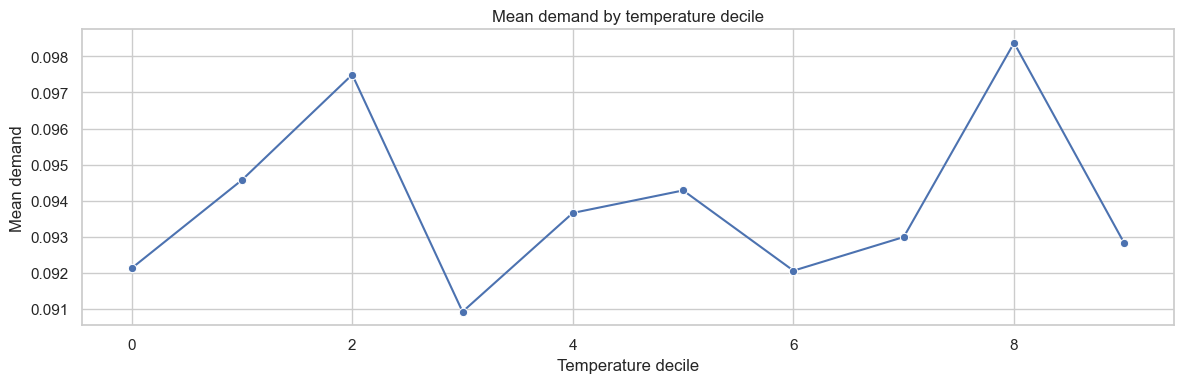

In [19]:
# Temperature relationship with target using decile bins.
temp_data = train[["Temperature", target]].dropna().copy()
temp_data["temperature_bin"] = pd.qcut(temp_data["Temperature"], q=10, duplicates="drop")
temp_summary = (
    temp_data.groupby("temperature_bin", observed=True)[target]
    .agg(rows="count", mean="mean", median="median")
    .reset_index()
)
show(temp_summary)

if HAS_PLOTS:
    plt.figure(figsize=(12, 4))
    sns.lineplot(data=temp_summary, x=temp_summary.index, y="mean", marker="o")
    plt.title("Mean demand by temperature decile")
    plt.xlabel("Temperature decile")
    plt.ylabel("Mean demand")
    plt.tight_layout()
    plt.show()


In [52]:
train[["Temperature", "demand"]].corr()

,Temperature,demand
Temperature,1.000000,0.003144
demand,0.003144,1.000000


Observation: Temperature vs Demand

- The correlation between Temperature and demand is extremely weak (r = 0.0031).
- Temperature decile analysis shows only minor fluctuations in average demand.
- No clear increasing, decreasing, or non-linear trend is observed across the temperature range.
- Median demand remains nearly constant across all temperature bins.
- Compared to RoadType, the effect of Temperature on demand is negligible.

Modeling Implication
- Temperature is unlikely to be a strong standalone predictor of demand.
- Missing Temperature values can be imputed using simple strategies (median, geohash median, or weather-specific median).
- Advanced temperature imputation methods are unlikely to significantly improve model performance.
- Temperature may still contribute through interactions with other variables, but its direct predictive power appears weak.

## 9. Train/Test Distribution Comparison

This checks whether the test set looks similar to train for shared features. Large differences can affect model performance and validation design.


In [20]:
# Numeric train/test comparison.
shared_numeric = [c for c in test.select_dtypes(include="number").columns if c in train.columns]
rows = []
for col in shared_numeric:
    rows.append({
        "column": col,
        "train_mean": train[col].mean(),
        "test_mean": test[col].mean(),
        "train_std": train[col].std(),
        "test_std": test[col].std(),
        "train_min": train[col].min(),
        "test_min": test[col].min(),
        "train_max": train[col].max(),
        "test_max": test[col].max(),
    })
show(pd.DataFrame(rows))


,column,train_mean,test_mean,train_std,test_std,train_min,test_min,train_max,test_max
0,Index,"38,649.000000","20,888.500000","22,314.443566","12,060.414110",0.000000,0.000000,"77,298.000000","41,777.000000"
1,day,48.101838,49.000000,0.302438,0.000000,48.000000,49.000000,49.000000,49.000000
2,NumberofLanes,2.014334,2.068984,0.904665,0.988519,1.000000,1.000000,5.000000,5.000000
3,Temperature,16.405354,16.457339,7.359835,7.351067,-14.935097,-21.314645,48.251433,45.230408


In [21]:
# Categorical train/test distribution shift table.
def normalized_labels(series):
    return series.map(lambda x: "Missing" if pd.isna(x) else str(x))

shift_rows = []
for col in ["RoadType", "NumberofLanes", "LargeVehicles", "Landmarks", "Weather", "day"]:
    train_labels = normalized_labels(train[col])
    test_labels = normalized_labels(test[col])
    levels = sorted(set(train_labels.unique()) | set(test_labels.unique()))
    for level in levels:
        train_mask = train_labels == level
        test_mask = test_labels == level
        shift_rows.append({
            "column": col,
            "level": level,
            "train_pct": train_mask.mean() * 100,
            "test_pct": test_mask.mean() * 100,
            "abs_diff_pct_points": abs(train_mask.mean() - test_mask.mean()) * 100,
        })
shift = pd.DataFrame(shift_rows).sort_values(["column", "abs_diff_pct_points"], ascending=[True, False])
show(shift)


,column,level,train_pct,test_pct,abs_diff_pct_points
11,Landmarks,No,32.674420,32.392647,0.281773
12,Landmarks,Yes,67.325580,67.607353,0.281773
9,LargeVehicles,Allowed,34.445465,37.340227,2.894762
10,LargeVehicles,Not Allowed,65.554535,62.659773,2.894762
5,NumberofLanes,2,31.212564,29.733352,1.479212
8,NumberofLanes,5,1.185009,2.537221,1.352212
7,NumberofLanes,4,1.197946,2.542008,1.344062
6,NumberofLanes,3,30.943479,29.695055,1.248424
4,NumberofLanes,1,35.461002,35.492364,0.031362
2,RoadType,Residential,89.561314,80.843985,8.717329


In [22]:
# Starter feature engineering block.
def build_features(df):
    out = add_time_features(df)
    out["RoadType_missing"] = out["RoadType"].isna().astype(int)
    out["Weather_missing"] = out["Weather"].isna().astype(int)
    out["Temperature_missing"] = out["Temperature"].isna().astype(int)
    out["RoadType"] = out["RoadType"].fillna("Unknown")
    out["Weather"] = out["Weather"].fillna("Unknown")
    out["Temperature"] = out["Temperature"].fillna(out["Temperature"].median())
    return out

train_fe = build_features(train)
test_fe = build_features(test)

feature_cols = [
    "geohash", "day", "timestamp", "hour", "minute", "quarter_hour_index",
    "RoadType", "NumberofLanes", "LargeVehicles", "Landmarks", "Temperature", "Weather",
    "RoadType_missing", "Weather_missing", "Temperature_missing",
]

print("Feature columns prepared:")
print(feature_cols)
show(train_fe[feature_cols + [target]].head())


Feature columns prepared:
['geohash', 'day', 'timestamp', 'hour', 'minute', 'quarter_hour_index', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather', 'RoadType_missing', 'Weather_missing', 'Temperature_missing']


,geohash,day,timestamp,hour,minute,quarter_hour_index,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,RoadType_missing,Weather_missing,Temperature_missing,demand
0,qp02z1,48,0:0,0,0,0,Unknown,1,Not Allowed,No,16.382587,Unknown,1,1,1,0.048804
1,qp02zt,48,0:0,0,0,0,Residential,3,Allowed,Yes,31.104565,Sunny,0,0,0,0.118507
2,qp08bj,48,0:0,0,0,0,Residential,1,Not Allowed,No,25.919267,Sunny,0,0,0,0.027132
3,qp08gt,48,0:0,0,0,0,Residential,1,Not Allowed,No,16.382587,Rainy,0,0,1,0.003272
4,qp02zq,48,0:0,0,0,0,Residential,1,Not Allowed,No,10.803667,Rainy,0,0,0,0.010819


## 11. Simple Baseline Submission Template

This baseline is intentionally simple and transparent. It predicts from historical averages in this order:

1. Mean demand by `geohash` and `minute`.
2. If missing, mean demand by `geohash`.
3. If missing, mean demand by `minute`.
4. If missing, global mean demand.

This is not meant to be the final model, but it creates a valid starting submission and a useful benchmark.


In [ ]:
geo_time_mean = (
    train_fe.groupby(["geohash", "minute"])[target]
    .mean()
    .rename("geo_time_mean")
    .reset_index()
)
geo_mean = train_fe.groupby("geohash")[target].mean().rename("geo_mean").reset_index()
time_mean = train_fe.groupby("minute")[target].mean().rename("time_mean").reset_index()
global_mean = train_fe[target].mean()

pred = test_fe[["Index", "geohash", "minute"]].copy()
pred = pred.merge(geo_time_mean, on=["geohash", "minute"], how="left")
pred = pred.merge(geo_mean, on="geohash", how="left")
pred = pred.merge(time_mean, on="minute", how="left")
pred["demand"] = (
    pred["geo_time_mean"]
    .fillna(pred["geo_mean"])
    .fillna(pred["time_mean"])
    .fillna(global_mean)
    .clip(0, 1)
)

baseline_submission = pred[["Index", "demand"]]
print(baseline_submission.shape)
show(baseline_submission.head())


# baseline_submission.to_csv("baseline_submission_geohash_time.csv", index=False)


(41778, 2)


,Index,demand
0,0,0.040048
1,1,0.031742
2,2,0.029433
3,3,0.070305
4,4,0.109744


## Final Data Quality Summary

- No duplicate rows were found in train or test.
- `geohash`, `day`, `timestamp` uniquely identify rows in both train and test.
- `demand` is the only train-only column and is the competition target.
- `RoadType`, `Temperature`, and `Weather` contain missing values in both train and test at similar rates.
- Test uses only day 49 and covers the 47 quarter-hour periods immediately after the day 49 training window.
- Most test geohashes are observed in train, but 10 geohashes are test-only and need fallback handling.
- `RoadType` and `NumberofLanes` show strong target separation, so they are likely important features.
- `Index` is an identifier and should be preserved for submission but usually excluded from modeling.


## Feature Engineering

In [101]:
train_fe = train.copy()
test_fe = test.copy()

Impute Missing Values

In [102]:
train_fe["roadtype_was_missing"] = train_fe["RoadType"].isna().astype(int)
test_fe["roadtype_was_missing"] = test_fe["RoadType"].isna().astype(int)

In [103]:
for df in [train_fe, test_fe]:
    df["temp_was_missing"] = df["Temperature"].isna().astype(int)

# Weather flag
for df in [train_fe, test_fe]:
    df["weather_was_missing"] = df["Weather"].isna().astype(int)

In [61]:
geo_roadtype = (
    train.groupby("geohash")["RoadType"]
         .nunique(dropna=True)
)

geo_roadtype.value_counts().sort_index()

RoadType
1    994
2    128
3    127
Name: count, dtype: int64

In [62]:
violations = geo_roadtype[geo_roadtype > 1]

print("Violating geohashes:", len(violations))
violations.head(20)

Violating geohashes: 255


geohash
qp02ze    2
qp02zh    3
qp02zj    3
qp02zn    2
qp02zr    3
qp02zt    3
qp02zv    2
qp02zw    3
qp02zx    3
qp02zy    2
qp02zz    3
qp03mg    3
qp03nb    2
qp03ny    2
qp03p2    3
qp03p7    3
qp03p8    2
qp03p9    2
qp03pb    3
qp03pc    2
Name: RoadType, dtype: int64

In [63]:
train.loc[
    train["geohash"].isin(violations.index)
].groupby("geohash")["RoadType"].unique()

geohash
qp02ze            [Residential, Highway, nan]
qp02zh         [Residential, Street, Highway]
qp02zj         [Residential, Street, Highway]
qp02zn                  [Residential, Street]
qp02zr         [Residential, Highway, Street]
                         ...                 
qp0dhb             [Residential, Street, nan]
qp0dhe    [Residential, nan, Street, Highway]
qp0dht    [Residential, nan, Street, Highway]
qp0dj0             [Residential, Street, nan]
qp0dj1                  [Residential, Street]
Name: RoadType, Length: 255, dtype: object

In [64]:
for col in [
    "RoadType",
    "NumberofLanes",
    "LargeVehicles",
    "Landmarks"
]:
    print("\n", col)
    print(
        train.groupby("geohash")[col]
             .nunique(dropna=True)
             .value_counts()
             .sort_index()
    )


 RoadType
RoadType
1    994
2    128
3    127
Name: count, dtype: int64

 NumberofLanes
NumberofLanes
1      45
2      66
3    1014
4      24
5     100
Name: count, dtype: int64

 LargeVehicles
LargeVehicles
1      66
2    1183
Name: count, dtype: int64

 Landmarks
Landmarks
1      67
2    1182
Name: count, dtype: int64


In [65]:
pd.crosstab(
    train["geohash"],
    train["RoadType"]
)

RoadType,Highway,Residential,Street
geohash,,,
qp02yc,0,12,0
qp02yf,0,1,0
qp02yy,0,2,0
qp02yz,0,29,0
qp02z1,0,32,0
...,...,...,...
qp0dn4,0,3,0
qp0dn5,0,7,0
qp0dnh,0,2,0


In [66]:
missing_rt = train[train["RoadType"].isna()]

missing_rt["geohash"].value_counts().head(20)

geohash
qp0d00    5
qp09b6    4
qp0989    4
qp09b2    4
qp03zz    4
qp03mr    4
qp03m9    4
qp03ms    3
qp09g8    3
qp09ut    3
qp03q3    3
qp03xz    3
qp094k    3
qp03jx    3
qp09f3    3
qp09gj    3
qp03x7    3
qp09m1    3
qp09e4    3
qp0dh9    3
Name: count, dtype: int64

In [67]:
train[train["geohash"] == "qp02zh"][
    ["geohash","RoadType","NumberofLanes","LargeVehicles","Landmarks"]
]

,geohash,RoadType,NumberofLanes,LargeVehicles,Landmarks
2158,qp02zh,Residential,2,Not Allowed,Yes
2919,qp02zh,Residential,1,Not Allowed,No
3715,qp02zh,Residential,1,Not Allowed,No
6248,qp02zh,Residential,1,Not Allowed,No
7125,qp02zh,Residential,3,Allowed,Yes
8020,qp02zh,Residential,1,Not Allowed,No
8913,qp02zh,Residential,3,Allowed,Yes
10687,qp02zh,Residential,3,Allowed,Yes
11578,qp02zh,Residential,2,Not Allowed,Yes
12484,qp02zh,Residential,3,Allowed,Yes


In [68]:
road_rules = (
    train.groupby(
        ["NumberofLanes",
         "LargeVehicles",
         "Landmarks"]
    )["RoadType"]
    .value_counts(normalize=True)
    .rename("pct")
    .reset_index()
)

road_rules.sort_values(
    ["NumberofLanes",
     "LargeVehicles",
     "Landmarks",
     "pct"],
    ascending=[True, True, True, False]
)

,NumberofLanes,LargeVehicles,Landmarks,RoadType,pct
0,1,Not Allowed,No,Residential,1.000000
1,1,Not Allowed,Yes,Street,1.000000
2,2,Allowed,No,Highway,1.000000
3,2,Not Allowed,Yes,Residential,1.000000
4,3,Allowed,Yes,Residential,0.962907
5,3,Allowed,Yes,Highway,0.037093
6,4,Allowed,Yes,Highway,1.000000
7,5,Allowed,No,Highway,1.000000


RoadType was found to be almost completely determined by the combination of NumberofLanes, LargeVehicles, and Landmarks. Seven of eight observed combinations mapped to a single RoadType with 100% probability. The remaining combination mapped to Residential in 96.3% of cases. Missing RoadType values were therefore imputed using a rule-based approach derived from these observed relationships.

In [104]:
def infer_roadtype(lanes, large, landmark):

    if lanes == 1 and large == "Not Allowed" and landmark == "No":
        return "Residential"

    elif lanes == 1 and large == "Not Allowed" and landmark == "Yes":
        return "Street"

    elif lanes == 2 and large == "Allowed" and landmark == "No":
        return "Highway"

    elif lanes == 2 and large == "Not Allowed" and landmark == "Yes":
        return "Residential"

    elif lanes == 4:
        return "Highway"

    elif lanes == 5:
        return "Highway"

    elif lanes == 3 and large == "Allowed" and landmark == "Yes":
        return "Residential"   # dominant class

    else:
        return "Unknown"

In [105]:
for df in [train_fe, test_fe]:

    mask = df["RoadType"].isna()

    df.loc[mask, "RoadType"] = df.loc[mask].apply(
        lambda row: infer_roadtype(
            row["NumberofLanes"],
            row["LargeVehicles"],
            row["Landmarks"]
        ),
        axis=1
    )

In [106]:
train_fe["RoadType"].isna().sum()
test_fe["RoadType"].isna().sum()

0

In [107]:
(train_fe["RoadType"] == "Unknown").sum()
(test_fe["RoadType"] == "Unknown").sum()

0

Weather Imputation

In [108]:
train_fe.groupby("Weather")["Temperature"]\
        .apply(lambda x: x.isna().mean())\
        .sort_values(ascending=False)

Weather
Foggy   0.032554
Sunny   0.032435
Rainy   0.032222
Snowy   0.031096
Name: Temperature, dtype: float64

In [109]:
train_fe.groupby("hour")["Temperature"]\
        .apply(lambda x: x.isna().mean())

hour
0    0.032502
1    0.032310
2    0.032099
3    0.032267
4    0.032311
5    0.032312
6    0.032196
7    0.032222
8    0.032221
9    0.032403
10   0.032303
11   0.032240
12   0.032340
13   0.032100
14   0.032333
15   0.032171
16   0.032258
17   0.032067
18   0.032879
19   0.032125
20   0.031735
21   0.032796
22   0.031950
23   0.032332
Name: Temperature, dtype: float64

In [110]:
train_fe.groupby("Weather")["Temperature"]\
        .agg(["count","mean","median","std"])

,count,mean,median,std
Weather,,,,
Foggy,19584,16.491600,16.475623,1.434400
Rainy,20153,10.934935,11.141699,1.969005
Snowy,7478,3.589905,4.403676,2.995841
Sunny,26818,24.016811,23.049061,4.031399


In [111]:
train_fe.groupby("hour")["Temperature"]\
        .agg(["mean","median"])

,mean,median
hour,,
0,16.549875,16.517269
1,16.347870,16.357196
2,16.241296,16.200602
3,16.433606,16.525514
4,16.183102,15.977779
5,16.462247,16.541338
6,16.364914,16.202270
7,16.425290,16.441874
8,16.485459,16.578207


In [112]:
for df in [train_fe, test_fe]:
    df["temp_was_missing"] = (
        df["Temperature"].isna().astype(int)
    )

In [113]:
temp_weather_median = (
    train_fe.groupby("Weather")["Temperature"]
            .median()
            .to_dict()
)

temp_weather_median

{'Foggy': 16.47562338407883,
 'Rainy': 11.14169937275097,
 'Snowy': 4.403675621167185,
 'Sunny': 23.049060673003773}

In [114]:
weather_consistency = (
    train.groupby(["geohash", "timestamp"])["Weather"]
         .nunique(dropna=True)
)

weather_consistency.value_counts().sort_index()

Weather
0      658
1    65755
2     4463
Name: count, dtype: int64

In [115]:
temp_stats = (
    train.groupby(["geohash", "timestamp"])["Temperature"]
         .agg(["count", "mean", "std"])
)

temp_stats["std"].describe()

count   6,015.000000
mean        5.771983
std         4.395067
min         0.000453
25%         2.328565
50%         4.850144
75%         8.247590
max        28.731439
Name: std, dtype: float64

In [116]:
train.groupby("timestamp")["Weather"]\
     .nunique(dropna=True)\
     .value_counts()

Weather
4    96
Name: count, dtype: int64

In [117]:
train.groupby("timestamp")["Temperature"]\
     .agg(["mean","std"])

,mean,std
timestamp,,
0:0,16.712012,7.196818
0:15,16.464464,7.399407
0:30,16.500695,7.083558
0:45,16.528642,7.288646
10:0,16.789907,7.489347
10:15,16.240969,7.779757
10:30,16.828565,7.520282
10:45,16.785303,7.421088
11:0,15.839864,7.691290


In [118]:
weather_lookup = (
    train_fe
    .dropna(subset=["Weather"])
    .groupby(["geohash","timestamp"])["Weather"]
    .agg(lambda x: x.mode().iloc[0])
)

In [119]:
for df in [train_fe, test_fe]:

    mask = df["Weather"].isna()

    idx = pd.MultiIndex.from_frame(
        df.loc[mask, ["geohash","timestamp"]]
    )

    df.loc[mask, "Weather"] = idx.map(weather_lookup)

In [99]:
remaining_weather = train_fe[
    train_fe["Weather"].isna()
]

remaining_weather.groupby(
    ["NumberofLanes","LargeVehicles","Landmarks"]
).size().sort_values(ascending=False)

NumberofLanes  LargeVehicles  Landmarks
3              Allowed        Yes          206
2              Not Allowed    Yes          199
1              Not Allowed    No           198
                              Yes           32
4              Allowed        Yes           13
5              Allowed        No             7
2              Allowed        No             4
dtype: int64

In [120]:
remaining_weather["Temperature"].describe()

count   637.000000
mean     16.708344
std       7.817518
min      -8.306298
25%      11.493010
50%      16.403745
75%      21.678617
max      39.771741
Name: Temperature, dtype: float64

In [121]:
for df in [train_fe, test_fe]:

    mask = df["Temperature"].isna()

    df.loc[mask, "Temperature"] = (
        df.loc[mask, "Weather"]
          .map(temp_weather_median)
    )

In [122]:
global_temp_median = train_fe["Temperature"].median()

for df in [train_fe, test_fe]:

    df["Temperature"] = (
        df["Temperature"]
          .fillna(global_temp_median)
    )

In [123]:
train_fe.isnull().sum()

Index                     0
geohash                   0
day                       0
timestamp                 0
demand                    0
RoadType                  0
NumberofLanes             0
LargeVehicles             0
Landmarks                 0
Temperature               0
Weather                 659
hour                      0
minute                    0
roadtype_was_missing      0
temp_was_missing          0
weather_was_missing       0
dtype: int64

In [124]:
test_fe.isnull().sum()

Index                    0
geohash                  0
day                      0
timestamp                0
RoadType                 0
NumberofLanes            0
LargeVehicles            0
Landmarks                0
Temperature              0
Weather                 54
roadtype_was_missing     0
temp_was_missing         0
weather_was_missing      0
dtype: int64

In [125]:
weather_temp_median = (
    train_fe.groupby("Weather")["Temperature"]
            .median()
            .to_dict()
)

In [126]:
def infer_weather(temp, weather_medians):

    return min(
        weather_medians,
        key=lambda w: abs(temp - weather_medians[w])
    )
    
for df in [train_fe, test_fe]:

    mask = df["Weather"].isna()

    df.loc[mask, "Weather"] = (
        df.loc[mask, "Temperature"]
          .apply(
              lambda t: infer_weather(
                  t,
                  weather_temp_median
              )
          )
    )

In [127]:
train_fe.isna().sum()

Index                   0
geohash                 0
day                     0
timestamp               0
demand                  0
RoadType                0
NumberofLanes           0
LargeVehicles           0
Landmarks               0
Temperature             0
Weather                 0
hour                    0
minute                  0
roadtype_was_missing    0
temp_was_missing        0
weather_was_missing     0
dtype: int64

In [128]:
test_fe.isna().sum()

Index                   0
geohash                 0
day                     0
timestamp               0
RoadType                0
NumberofLanes           0
LargeVehicles           0
Landmarks               0
Temperature             0
Weather                 0
roadtype_was_missing    0
temp_was_missing        0
weather_was_missing     0
dtype: int64

In [129]:
print(train_fe.shape)
print(test_fe.shape)

print(train_fe.isna().sum().sum())
print(test_fe.isna().sum().sum())

(77299, 16)
(41778, 13)
0
0


Feature Engineering

In [132]:
def add_time_features(df):

    df = df.copy()

    parts = df["timestamp"].str.split(":", expand=True)

    df["hour"] = parts[0].astype(int)
    df["minute"] = parts[1].astype(int)

    return df


train_fe = add_time_features(train_fe)
test_fe = add_time_features(test_fe)

In [141]:
train_fe[["hour", "minute"]].describe()

,hour,minute
count,"77,299.000000","77,299.000000"
mean,9.101347,22.271310
std,6.856045,16.853641
min,0.000000,0.000000
25%,3.000000,0.000000
50%,8.000000,15.000000
75%,14.000000,30.000000
max,23.000000,45.000000


In [142]:
import numpy as np

for df in [train_fe, test_fe]:

    # Hour cycle (24-hour clock)
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

    # Minute cycle (0,15,30,45)
    df["minute_sin"] = np.sin(2 * np.pi * df["minute"] / 60)
    df["minute_cos"] = np.cos(2 * np.pi * df["minute"] / 60)

In [143]:
train_fe[
    [
        "hour",
        "hour_sin",
        "hour_cos",
        "minute",
        "minute_sin",
        "minute_cos"
    ]
].head(10)

,hour,hour_sin,hour_cos,minute,minute_sin,minute_cos
0,0,0.000000,1.000000,0,0.000000,1.000000
1,0,0.000000,1.000000,0,0.000000,1.000000
2,0,0.000000,1.000000,0,0.000000,1.000000
3,0,0.000000,1.000000,0,0.000000,1.000000
4,0,0.000000,1.000000,0,0.000000,1.000000
5,0,0.000000,1.000000,0,0.000000,1.000000
6,0,0.000000,1.000000,0,0.000000,1.000000
7,0,0.000000,1.000000,0,0.000000,1.000000
8,0,0.000000,1.000000,0,0.000000,1.000000
9,0,0.000000,1.000000,0,0.000000,1.000000


In [144]:
train_fe[
    [
        "hour_sin",
        "hour_cos",
        "minute_sin",
        "minute_cos"
    ]
].describe()

,hour_sin,hour_cos,minute_sin,minute_cos
count,"77,299.000000","77,299.000000","77,299.000000","77,299.000000"
mean,0.182811,0.065783,-0.001552,0.011087
std,0.623026,0.757696,0.703059,0.711052
min,-1.000000,-1.000000,-1.000000,-1.000000
25%,-0.258819,-0.707107,0.000000,-0.000000
50%,0.258819,0.000000,0.000000,0.000000
75%,0.707107,0.866025,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000


In [145]:
geo_freq = train_fe["geohash"].value_counts()

train_fe["geo_freq"] = train_fe["geohash"].map(geo_freq)

test_fe["geo_freq"] = (
    test_fe["geohash"]
           .map(geo_freq)
           .fillna(0)
)

In [146]:
train_fe["geo_freq"].describe()

count   77,299.000000
mean        82.465556
std         23.521613
min          1.000000
25%         71.000000
50%         89.000000
75%        102.000000
max        105.000000
Name: geo_freq, dtype: float64

In [147]:
test_fe["geo_freq"].describe()

count   41,778.000000
mean        78.524822
std         25.513581
min          0.000000
25%         64.000000
50%         85.000000
75%        100.000000
max        105.000000
Name: geo_freq, dtype: float64

In [148]:
(test_fe["geo_freq"] == 0).sum()

25

In [149]:
seen_geos = set(train_fe["geohash"])

train_fe["geo_seen"] = 1

test_fe["geo_seen"] = (
    test_fe["geohash"]
          .isin(seen_geos)
          .astype(int)
)

In [150]:
test_fe["geo_seen"].value_counts()

geo_seen
1    41753
0       25
Name: count, dtype: int64

In [151]:
for df in [train_fe, test_fe]:

    df["quarter_hour"] = (
        df["minute"] // 15
    )

Baseline Modelling

In [152]:
drop_cols = [
    "Index",
    "demand"
]

In [153]:
cat_features = [
    "geohash",
    "RoadType",
    "Weather",
    "LargeVehicles",
    "Landmarks",
    "quarter_hour"
]

In [154]:
features = [
    "geohash",
    "RoadType",
    "Weather",
    "LargeVehicles",
    "Landmarks",

    "NumberofLanes",
    "Temperature",

    "hour",
    "minute",
    "quarter_hour",

    "hour_sin",
    "hour_cos",

    "minute_sin",
    "minute_cos",

    "geo_freq",
    "geo_seen",

    "temp_was_missing",
    "weather_was_missing"
]

In [155]:
X = train_fe[features]
y = train_fe["demand"]

X_test = test_fe[features]

In [156]:
train_fe["day"].value_counts()

day
48    69427
49     7872
Name: count, dtype: int64

In [157]:
from sklearn.model_selection import KFold
import numpy as np

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [158]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error

oof = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

scores = []
models = []

In [159]:
for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):

    X_tr = X.iloc[tr_idx]
    X_val = X.iloc[val_idx]

    y_tr = y.iloc[tr_idx]
    y_val = y.iloc[val_idx]

    model = CatBoostRegressor(
        iterations=3000,
        learning_rate=0.03,
        depth=8,

        loss_function="RMSE",
        eval_metric="RMSE",

        random_seed=42,
        verbose=200
    )

    model.fit(
        X_tr,
        y_tr,

        cat_features=cat_features,

        eval_set=(X_val, y_val),

        use_best_model=True
    )

    val_pred = model.predict(X_val)

    rmse = np.sqrt(
        mean_squared_error(y_val, val_pred)
    )

    print(f"Fold {fold+1}: {rmse:.6f}")

    scores.append(rmse)

    oof[val_idx] = val_pred

    test_preds += model.predict(X_test) / kf.n_splits

    models.append(model)

0:	learn: 0.1388279	test: 0.1388331	best: 0.1388331 (0)	total: 532ms	remaining: 26m 34s
200:	learn: 0.0422137	test: 0.0417462	best: 0.0417462 (200)	total: 48.2s	remaining: 11m 10s
400:	learn: 0.0389912	test: 0.0393720	best: 0.0393720 (400)	total: 1m 22s	remaining: 8m 57s
600:	learn: 0.0369598	test: 0.0381871	best: 0.0381871 (600)	total: 2m	remaining: 8m 1s
800:	learn: 0.0355683	test: 0.0373853	best: 0.0373852 (799)	total: 2m 42s	remaining: 7m 25s
1000:	learn: 0.0346461	test: 0.0369643	best: 0.0369643 (1000)	total: 3m 21s	remaining: 6m 41s
1200:	learn: 0.0336595	test: 0.0365028	best: 0.0365023 (1199)	total: 4m 2s	remaining: 6m 3s
1400:	learn: 0.0329176	test: 0.0362065	best: 0.0362065 (1400)	total: 4m 42s	remaining: 5m 22s
1600:	learn: 0.0322131	test: 0.0359173	best: 0.0359173 (1600)	total: 5m 18s	remaining: 4m 38s
1800:	learn: 0.0316994	test: 0.0357542	best: 0.0357534 (1794)	total: 6m 4s	remaining: 4m 2s
2000:	learn: 0.0312074	test: 0.0355936	best: 0.0355928 (1993)	total: 6m 51s	remaini

In [160]:
print("Mean RMSE :", np.mean(scores))
print("Std RMSE  :", np.std(scores))

Mean RMSE : 0.03520728761186638
Std RMSE  : 0.0005851898825836309


In [169]:

pd.DataFrame(test_preds).to_csv("baseline_predicts.csv")

In [161]:
scores

[0.035117264234293157,
 0.035896584789756464,
 0.03414783273026926,
 0.035455725161938276,
 0.035419031143074764]

In [162]:
imp = pd.DataFrame({
    "feature": features,
    "importance": models[-1].get_feature_importance()
})

imp = imp.sort_values(
    "importance",
    ascending=False
)

imp.head(20)

,feature,importance
1,RoadType,58.599028
0,geohash,10.228525
5,NumberofLanes,7.719831
3,LargeVehicles,6.552205
14,geo_freq,5.618671
10,hour_sin,3.348549
11,hour_cos,3.326532
7,hour,2.566785
6,Temperature,0.555863
2,Weather,0.545779


In [172]:
for df in [train_fe, test_fe]:

    df["RoadType_hour"] = (
        df["RoadType"].astype(str)
        + "_"
        + df["hour"].astype(str)
    )

In [173]:
cat_features = [
    "geohash",
    "RoadType",
    "Weather",
    "LargeVehicles",
    "Landmarks",
    "quarter_hour",
    "RoadType_hour"
]

In [ ]:
features=[
    "geohash",
    "RoadType",
    "Weather",
    "LargeVehicles",
    "Landmarks",

    "RoadType_hour",

    "NumberofLanes",
    "Temperature",

    "hour",
    "minute",
    "quarter_hour",

    "hour_sin",
    "hour_cos",

    "minute_sin",
    "minute_cos",

    "geo_freq",
    "geo_seen",

    "temp_was_missing",
    "weather_was_missing"
]

In [175]:
train_fe["RoadType_hour"].nunique()

72

In [177]:
X = train_fe[features]
y = train_fe["demand"]

X_test = test_fe[features]

In [178]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error

oof_2 = np.zeros(len(X))
test_preds_2 = np.zeros(len(X_test))

scores_2 = []
models_2 = []

In [179]:
for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):

    X_tr = X.iloc[tr_idx]
    X_val = X.iloc[val_idx]

    y_tr = y.iloc[tr_idx]
    y_val = y.iloc[val_idx]

    model = CatBoostRegressor(
        iterations=3000,
        learning_rate=0.03,
        depth=8,

        loss_function="RMSE",
        eval_metric="RMSE",

        random_seed=42,
        verbose=200
    )

    model.fit(
        X_tr,
        y_tr,

        cat_features=cat_features,

        eval_set=(X_val, y_val),

        use_best_model=True
    )

    val_pred = model.predict(X_val)

    rmse = np.sqrt(
        mean_squared_error(y_val, val_pred)
    )

    print(f"Fold {fold+1}: {rmse:.6f}")

    scores_2.append(rmse)

    oof_2[val_idx] = val_pred

    test_preds_2 += model.predict(X_test) / kf.n_splits

    models_2.append(model)

0:	learn: 0.1387831	test: 0.1387917	best: 0.1387917 (0)	total: 391ms	remaining: 19m 32s
200:	learn: 0.0411281	test: 0.0404710	best: 0.0404710 (200)	total: 48.4s	remaining: 11m 14s
400:	learn: 0.0385701	test: 0.0389152	best: 0.0389152 (400)	total: 1m 32s	remaining: 9m 57s
600:	learn: 0.0365261	test: 0.0376161	best: 0.0376129 (598)	total: 2m 13s	remaining: 8m 54s
800:	learn: 0.0350795	test: 0.0369404	best: 0.0369404 (800)	total: 2m 57s	remaining: 8m 8s
1000:	learn: 0.0340671	test: 0.0365736	best: 0.0365721 (999)	total: 3m 44s	remaining: 7m 28s
1200:	learn: 0.0332448	test: 0.0362902	best: 0.0362901 (1198)	total: 4m 31s	remaining: 6m 46s
1400:	learn: 0.0324444	test: 0.0360029	best: 0.0360011 (1398)	total: 5m 12s	remaining: 5m 57s
1600:	learn: 0.0317109	test: 0.0357246	best: 0.0357246 (1600)	total: 5m 54s	remaining: 5m 9s
1800:	learn: 0.0311062	test: 0.0355522	best: 0.0355501 (1794)	total: 6m 36s	remaining: 4m 23s
2000:	learn: 0.0305508	test: 0.0353572	best: 0.0353572 (2000)	total: 7m 21s	r

In [181]:
print("Mean RMSE :", np.mean(scores_2))
print("Std RMSE  :", np.std(scores_2))

Mean RMSE : 0.03457158331159414
Std RMSE  : 0.0007154785567401367


In [182]:
scores_2

[0.03487240851157746,
 0.03522910349816437,
 0.03319319054225482,
 0.03462583039912289,
 0.03493738360685116]

In [183]:
imp_2 = pd.DataFrame({
    "feature": features,
    "importance": models_2[-1].get_feature_importance()
})

imp_2 = imp_2.sort_values(
    "importance",
    ascending=False
)

imp_2.head(20)

,feature,importance
1,RoadType,43.399801
0,geohash,14.934406
5,RoadType_hour,11.039000
6,NumberofLanes,7.245824
3,LargeVehicles,6.513365
15,geo_freq,4.436894
12,hour_cos,3.260348
10,quarter_hour,2.549202
11,hour_sin,2.406456
8,hour,2.353153


In [184]:
pd.DataFrame(test_preds_2).to_csv("baseline_predicts_2.csv")

Experiment 2: Adding RoadType_hour

Performance Impact

| Model | Mean RMSE | Std RMSE |
|---|---|---:|
| Baseline | 0.035207 |	0.000585 |
| + RoadType_hour | 0.034572 | 0.000715 |

Improvement:

-0.035207 -> 0.034572
-Δ = -0.000636

Relative improvement:

≈ 1.8%

This is a meaningful gain and much larger than fold-to-fold noise.

Observation 1: Time behavior depends on RoadType

The new feature became important:

-Feature	Importance
-RoadType_hour	11.04

This confirms observation during EDA:

-Highways have strong hourly variation.
-Residential roads have strong hourly variation.
-Streets are relatively stable.

- The same hour affects different road types differently, and CatBoost benefited from explicitly seeing this interaction.

Observation 2: RoadType is still the dominant signal

Before:

RoadType = 58.6

After:

- RoadType      = 43.4
- RoadType_hour = 11.0

Combined:

54.4

Road-related information still explains the majority of the model's predictive power.

This aligns perfectly with our EDA where:

- Highway mean demand      ≈ 0.61
- Street mean demand       ≈ 0.27
- Residential mean demand  ≈ 0.057

Observation 3: Geohash became more important
|Feature	|Before	|After|
|---|---|---:|
|geohash	|10.2	|14.9|

After the model learned the temporal road pattern through RoadType_hour, it relied more heavily on location-specific information.

This suggests:

RoadType explains broad traffic behavior, while Geohash explains local deviations around that behavior.

Observation 4: Time features remain useful

Combined time-related importance:

- hour_sin      2.41
- hour_cos      3.26
- hour          2.35
- quarter_hour  2.55

Total:

≈ 10.6

This confirms that traffic demand has a meaningful temporal pattern beyond road characteristics.

Observation 5: Weather and Temperature remain weak

- Feature	Importance
- Temperature	0.62
- Weather	0.62

Despite all the effort spent imputing them, they contribute very little to prediction.

The imputation was anyways necessary for completeness, but demand is clearly driven more by:

- RoadType
- Location
- Time

than by weather conditions.

Observation 6: Missingness carries no signal
- Feature	Importance
- temp_was_missing	0.035
- weather_was_missing	0.019
- geo_seen	0.000

Missing-value patterns do not appear predictive.

These features can likely be removed later without affecting performance.

Overall Conclusion

The experiment validates our EDA hypothesis:

Demand is most probably a function of RoadType + Time + Location.

The addition of RoadType_hour successfully captured part of that interaction and delivered a genuine CV improvement.

Current hierarchy of signal
1. RoadType
2. Geohash
3. RoadType_Hour
4. NumberofLanes
5. LargeVehicles
6. Time features
7. Weather / Temperature
8. Missingness indicators


The strongest unexplored interaction is now:

geohash_hour

because EDA showed that traffic patterns vary significantly by both location and time. geo_hour is the logical next feature to test.

The geohash_hour can give around 30k categories (1249 x 24) -> high cardinality

Still, we earlier saw unique(geohash,hour) ~ 21k.

Catboost may handle it, let's see

In [185]:
for df in [train_fe, test_fe]:
    df["geo_hour"] =(
        df["geohash"].astype(str)
        + "_"
        + df["hour"].astype(str)
    )

In [186]:
cat_features.append("geo_hour")

In [187]:
features.append("geo_hour")

In [192]:
remove_fet = ["temp_was_missing", "weather_was_missing", "geo_seen"]

for item in remove_fet:
    if item in features:
        features.remove(item)
        
    
    if item in cat_features:
        cat_features.remove(item)
          


In [193]:
features

['geohash',
 'RoadType',
 'Weather',
 'LargeVehicles',
 'Landmarks',
 'RoadType_hour',
 'NumberofLanes',
 'Temperature',
 'hour',
 'minute',
 'quarter_hour',
 'hour_sin',
 'hour_cos',
 'minute_sin',
 'minute_cos',
 'geo_freq',
 'geo_hour']

In [194]:
cat_features

['geohash',
 'RoadType',
 'Weather',
 'LargeVehicles',
 'Landmarks',
 'quarter_hour',
 'RoadType_hour',
 'geo_hour']

In [197]:
X = train_fe[features]
y = train_fe["demand"]

X_test = test_fe[features]

In [198]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error

oof_3 = np.zeros(len(X))
test_preds_3 = np.zeros(len(X_test))

scores_3 = []
models_3 = []

In [199]:
for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):

    X_tr = X.iloc[tr_idx]
    X_val = X.iloc[val_idx]

    y_tr = y.iloc[tr_idx]
    y_val = y.iloc[val_idx]

    model = CatBoostRegressor(
        iterations=3000,
        learning_rate=0.03,
        depth=8,

        loss_function="RMSE",
        eval_metric="RMSE",

        random_seed=42,
        verbose=200
    )

    model.fit(
        X_tr,
        y_tr,

        cat_features=cat_features,
        eval_set=(X_val, y_val),
        use_best_model=True
    )

    val_pred = model.predict(X_val)

    rmse = np.sqrt(
        mean_squared_error(y_val, val_pred)
    )

    print(f"Fold {fold+1}: {rmse:.6f}")

    scores_3.append(rmse)

    oof_3[val_idx] = val_pred

    test_preds_3 += model.predict(X_test) / kf.n_splits

    models_3.append(model)

0:	learn: 0.1387781	test: 0.1387753	best: 0.1387753 (0)	total: 423ms	remaining: 21m 7s
200:	learn: 0.0410639	test: 0.0401924	best: 0.0401924 (200)	total: 1m 1s	remaining: 14m 12s
400:	learn: 0.0383972	test: 0.0385679	best: 0.0385644 (399)	total: 2m 58s	remaining: 19m 15s
600:	learn: 0.0360153	test: 0.0371933	best: 0.0371933 (599)	total: 5m 38s	remaining: 22m 32s
800:	learn: 0.0347006	test: 0.0366013	best: 0.0366013 (800)	total: 7m 7s	remaining: 19m 33s
1000:	learn: 0.0338432	test: 0.0362839	best: 0.0362839 (1000)	total: 8m 24s	remaining: 16m 48s
1200:	learn: 0.0330054	test: 0.0360016	best: 0.0360016 (1200)	total: 9m 20s	remaining: 13m 59s
1400:	learn: 0.0322458	test: 0.0357922	best: 0.0357920 (1399)	total: 10m 17s	remaining: 11m 44s
1600:	learn: 0.0316521	test: 0.0356184	best: 0.0356184 (1600)	total: 11m 8s	remaining: 9m 44s
1800:	learn: 0.0310904	test: 0.0354622	best: 0.0354600 (1799)	total: 12m 8s	remaining: 8m 5s
2000:	learn: 0.0304881	test: 0.0352914	best: 0.0352914 (2000)	total: 1

In [200]:
print("Mean RMSE :", np.mean(scores_3))
print("Std RMSE  :", np.std(scores_3))

Mean RMSE : 0.03448693043877969
Std RMSE  : 0.0007298303800182458


In [201]:
imp_3 = pd.DataFrame({
    "feature": features,
    "importance": models_3[-1].get_feature_importance()
})

imp_3 = imp_3.sort_values(
    "importance",
    ascending=False
)

imp_3.head(20)

,feature,importance
1,RoadType,39.601522
0,geohash,15.908462
5,RoadType_hour,15.564264
6,NumberofLanes,9.009183
3,LargeVehicles,4.467606
12,hour_cos,3.488195
15,geo_freq,3.039017
11,hour_sin,2.393355
8,hour,2.180621
16,geo_hour,1.709668


In [202]:
scores_3

[0.03487313997484017,
 0.03491835016814798,
 0.033113106081387816,
 0.03438693323854644,
 0.03514312273097607]

In [203]:
pd.DataFrame(test_preds_3).to_csv("baseline_predicts_3.csv")

In [205]:
test.shape

(41778, 10)

## Advannced Feature Engineering

In [207]:
train_fe_te = train_fe.copy()
test_fe_te = test_fe.copy()

In [208]:
train_fe_te["geo_te"] = np.nan

In [209]:
from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [210]:
global_mean = train_fe_te["demand"].mean()

print(global_mean)

0.09394238120172715


In [211]:
for tr_idx, val_idx in kf.split(train_fe_te):

    tr = train_fe_te.iloc[tr_idx]
    val = train_fe_te.iloc[val_idx]

    geo_mean = (
        tr
        .groupby("geohash")["demand"]
        .mean()
    )

    train_fe_te.loc[val.index, "geo_te"] = (
        val["geohash"]
        .map(geo_mean)
        .fillna(global_mean)
    )

In [212]:
train_fe_te["geo_te"].isna().sum()

0

In [213]:
geo_mean_full = (
    train_fe_te
    .groupby("geohash")["demand"]
    .mean()
)

In [214]:
test_fe_te["geo_te"] = (
    test_fe_te["geohash"]
    .map(geo_mean_full)
    .fillna(global_mean)
)

In [215]:
train_fe_te["geo_te"].describe()

count   77,299.000000
mean         0.094022
std          0.118625
min          0.000297
25%          0.027527
50%          0.055874
75%          0.107336
max          0.964961
Name: geo_te, dtype: float64

In [216]:
train_fe_te[["geo_te", "demand"]].corr()

,geo_te,demand
geo_te,1.000000,0.828717
demand,0.828717,1.000000


In [217]:
train_fe_te[["Temperature", "demand"]].corr()

,Temperature,demand
Temperature,1.000000,0.002307
demand,0.002307,1.000000


In [218]:
features.append("geo_te")

In [220]:
X = train_fe_te[features]
y = train_fe_te["demand"]

X_test = test_fe_te[features]

In [221]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error

oof_4 = np.zeros(len(X))
test_preds_4 = np.zeros(len(X_test))

scores_4 = []
models_4 = []

In [222]:
for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):

    X_tr = X.iloc[tr_idx]
    X_val = X.iloc[val_idx]

    y_tr = y.iloc[tr_idx]
    y_val = y.iloc[val_idx]

    model = CatBoostRegressor(
        iterations=3000,
        learning_rate=0.03,
        depth=8,

        loss_function="RMSE",
        eval_metric="RMSE",

        random_seed=42,
        verbose=200
    )

    model.fit(
        X_tr,
        y_tr,

        cat_features=cat_features,
        eval_set=(X_val, y_val),
        use_best_model=True
    )

    val_pred = model.predict(X_val)

    rmse = np.sqrt(
        mean_squared_error(y_val, val_pred)
    )

    print(f"Fold {fold+1}: {rmse:.6f}")

    scores_4.append(rmse)

    oof_4[val_idx] = val_pred

    test_preds_4 += model.predict(X_test) / kf.n_splits

    models_4.append(model)

0:	learn: 0.1385243	test: 0.1385411	best: 0.1385411 (0)	total: 189ms	remaining: 9m 27s
200:	learn: 0.0378900	test: 0.0386110	best: 0.0386110 (200)	total: 38.5s	remaining: 8m 56s
400:	learn: 0.0353759	test: 0.0369787	best: 0.0369787 (400)	total: 1m 26s	remaining: 9m 21s
600:	learn: 0.0338109	test: 0.0362054	best: 0.0362054 (600)	total: 2m 16s	remaining: 9m 3s
800:	learn: 0.0324667	test: 0.0356159	best: 0.0356159 (800)	total: 3m 2s	remaining: 8m 20s
1000:	learn: 0.0314881	test: 0.0352634	best: 0.0352630 (999)	total: 3m 52s	remaining: 7m 43s
1200:	learn: 0.0307509	test: 0.0350593	best: 0.0350575 (1193)	total: 5m 8s	remaining: 7m 41s
1400:	learn: 0.0301078	test: 0.0348901	best: 0.0348901 (1400)	total: 6m 8s	remaining: 7m
1600:	learn: 0.0295737	test: 0.0347399	best: 0.0347398 (1599)	total: 6m 58s	remaining: 6m 5s
1800:	learn: 0.0290608	test: 0.0346435	best: 0.0346416 (1798)	total: 7m 45s	remaining: 5m 10s
2000:	learn: 0.0285902	test: 0.0345396	best: 0.0345396 (2000)	total: 8m 33s	remaining:

In [223]:
print("Mean RMSE :", np.mean(scores_4))
print("Std RMSE  :", np.std(scores_4))

Mean RMSE : 0.03348911152648285
Std RMSE  : 0.0006602374354897074


In [224]:
scores_4

[0.03418330661543005,
 0.033837986521562995,
 0.032310875498286894,
 0.03325788710405603,
 0.033855501893078295]

In [225]:
imp_4 = pd.DataFrame({
    "feature": features,
    "importance": models_4[-1].get_feature_importance()
})

imp_4 = imp_4.sort_values(
    "importance",
    ascending=False
)

imp_4.head(20)

,feature,importance
17,geo_te,26.112567
1,RoadType,25.209386
5,RoadType_hour,11.077513
6,NumberofLanes,7.055556
3,LargeVehicles,6.845491
0,geohash,5.303908
12,hour_cos,4.589155
11,hour_sin,3.552039
8,hour,3.067799
16,geo_hour,2.595531


In [226]:
pd.DataFrame(test_preds_4).to_csv("baseline_predicts_4.csv")

In [227]:
train_fe_te["geo_hour_key"] = (
    train_fe_te["geohash"].astype(str)
    + "_"
    + train_fe_te["hour"].astype(str)
)

test_fe_te["geo_hour_key"] = (
    test_fe_te["geohash"].astype(str)
    + "_"
    + test_fe_te["hour"].astype(str)
)

In [228]:
train_fe_te["geo_hour_te"] = np.nan

In [229]:
for tr_idx, val_idx in kf.split(train_fe_te):

    tr = train_fe_te.iloc[tr_idx]
    val = train_fe_te.iloc[val_idx]

    geo_hour_mean = (
        tr
        .groupby("geo_hour_key")["demand"]
        .mean()
    )

    train_fe_te.loc[val.index, "geo_hour_te"] = (
        val["geo_hour_key"]
        .map(geo_hour_mean)
        .fillna(global_mean)
    )

In [230]:
train_fe_te["geo_hour_te"].isna().sum()

0

In [231]:
geo_hour_mean_full = (
    train_fe_te
    .groupby("geo_hour_key")["demand"]
    .mean()
)

test_fe_te["geo_hour_te"] = (
    test_fe_te["geo_hour_key"]
    .map(geo_hour_mean_full)
    .fillna(global_mean)
)

In [232]:
test_fe_te["geo_hour_te"].isna().sum()

0

In [233]:
train_fe_te["geo_hour_te"].describe()

count   77,299.000000
mean         0.097662
std          0.137588
min          0.000004
25%          0.023919
50%          0.056278
75%          0.107504
max          1.000000
Name: geo_hour_te, dtype: float64

In [234]:
train_fe_te[["geo_hour_te", "demand"]].corr()

,geo_hour_te,demand
geo_hour_te,1.000000,0.946505
demand,0.946505,1.000000


In [242]:
features.append("geo_hour_te")

In [247]:
features = list(dict.fromkeys(features))

In [248]:
features.count("geo_hour_te")

1

In [249]:
X = train_fe_te[features]
X_test = test_fe_te[features]
y = train_fe_te["demand"]

In [250]:
"geo_hour_te" in X.columns

True

In [251]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error

oof_5 = np.zeros(len(X))
test_preds_5 = np.zeros(len(X_test))

scores_5 = []
models_5 = []

In [252]:
for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):

    X_tr = X.iloc[tr_idx]
    X_val = X.iloc[val_idx]

    y_tr = y.iloc[tr_idx]
    y_val = y.iloc[val_idx]

    model = CatBoostRegressor(
        iterations=3000,
        learning_rate=0.03,
        depth=8,

        loss_function="RMSE",
        eval_metric="RMSE",

        random_seed=42,
        verbose=200
    )

    model.fit(
        X_tr,
        y_tr,

        cat_features=cat_features,
        eval_set=(X_val, y_val),
        use_best_model=True
    )

    val_pred = model.predict(X_val)

    rmse = np.sqrt(
        mean_squared_error(y_val, val_pred)
    )

    print(f"Fold {fold+1}: {rmse:.6f}")

    scores_5.append(rmse)

    oof_5[val_idx] = val_pred

    test_preds_5 += model.predict(X_test) / kf.n_splits

    models_5.append(model)

0:	learn: 0.1383436	test: 0.1383659	best: 0.1383659 (0)	total: 229ms	remaining: 11m 26s
200:	learn: 0.0306746	test: 0.0311288	best: 0.0311288 (200)	total: 47.4s	remaining: 10m 59s
400:	learn: 0.0278684	test: 0.0292175	best: 0.0292175 (400)	total: 1m 38s	remaining: 10m 36s
600:	learn: 0.0259844	test: 0.0280396	best: 0.0280396 (600)	total: 2m 28s	remaining: 9m 53s
800:	learn: 0.0246203	test: 0.0274246	best: 0.0274214 (799)	total: 3m 20s	remaining: 9m 10s
1000:	learn: 0.0235405	test: 0.0268379	best: 0.0268379 (1000)	total: 4m 12s	remaining: 8m 24s
1200:	learn: 0.0227083	test: 0.0264777	best: 0.0264777 (1200)	total: 5m 18s	remaining: 7m 57s
1400:	learn: 0.0220114	test: 0.0261832	best: 0.0261832 (1400)	total: 6m 31s	remaining: 7m 26s
1600:	learn: 0.0213967	test: 0.0259154	best: 0.0259154 (1599)	total: 7m 46s	remaining: 6m 47s
1800:	learn: 0.0208561	test: 0.0257428	best: 0.0257428 (1800)	total: 9m 1s	remaining: 6m
2000:	learn: 0.0203597	test: 0.0255821	best: 0.0255816 (1999)	total: 10m 13s	r

In [253]:
print("Mean RMSE :", np.mean(scores_5))
print("Std RMSE  :", np.std(scores_5))

Mean RMSE : 0.025431083483358784
Std RMSE  : 0.00047789414875054907


In [254]:
imp_5 = pd.DataFrame({
    "feature": features,
    "importance": models_5[-1].get_feature_importance()
})

imp_5 = imp_5.sort_values(
    "importance",
    ascending=False
)

imp_5.head(20)

,feature,importance
18,geo_hour_te,48.967698
1,RoadType,14.326851
5,RoadType_hour,7.290994
17,geo_te,6.060920
3,LargeVehicles,5.008474
16,geo_hour,4.751251
6,NumberofLanes,4.660738
0,geohash,1.944338
8,hour,1.475475
15,geo_freq,0.970658


In [255]:
vc = train_fe_te["geo_hour_key"].value_counts()

vc.describe()

count   21,089.000000
mean         3.665371
std          1.537954
min          1.000000
25%          3.000000
50%          4.000000
75%          4.000000
max          8.000000
Name: count, dtype: float64

In [256]:
print((vc == 1).sum())
print((vc <= 2).sum())
print((vc <= 3).sum())
print((vc <= 5).sum())

2371
4294
6571
19620


In [257]:
pd.DataFrame(test_preds_5).to_csv("baseline_predicts_5.csv")

Our performance on leaderboard dropped. This implies that geo_hour_te is just overfitting the data, however geo_te contains real signal


In [259]:
features = [f for f in features if f != "geo_hour_te"]
"geo_hour_te" in features

False

In [260]:
train_fe_te["geo_hour_key"].head()

0    qp02z1_0
1    qp02zt_0
2    qp08bj_0
3    qp08gt_0
4    qp02zq_0
Name: geo_hour_key, dtype: object

In [261]:
train_fe_te["geo_hour_te_smooth"] = np.nan

In [262]:
global_mean = train_fe_te["demand"].mean()

In [263]:
m = 10

for tr_idx, val_idx in kf.split(train_fe_te):

    tr = train_fe_te.iloc[tr_idx]
    val = train_fe_te.iloc[val_idx]

    stats = (
        tr
        .groupby("geo_hour_key")["demand"]
        .agg(["mean", "count"])
    )

    stats["smooth"] = (
        stats["count"] * stats["mean"]
        + m * global_mean
    ) / (
        stats["count"] + m
    )

    train_fe_te.loc[val.index, "geo_hour_te_smooth"] = (
        val["geo_hour_key"]
        .map(stats["smooth"])
        .fillna(global_mean)
    )

In [264]:
train_fe_te["geo_hour_te_smooth"].isna().sum()

0

In [265]:
stats_full = (
    train_fe_te
    .groupby("geo_hour_key")["demand"]
    .agg(["mean", "count"])
)

In [266]:
m = 10

stats_full["smooth"] = (
    stats_full["count"] * stats_full["mean"]
    + m * global_mean
) / (
    stats_full["count"] + m
)

In [267]:
test_fe_te["geo_hour_te_smooth"] = (
    test_fe_te["geo_hour_key"]
    .map(stats_full["smooth"])
    .fillna(global_mean)
)

In [268]:
train_fe_te[
    ["geo_hour_te_smooth", "demand"]
].corr()

,geo_hour_te_smooth,demand
geo_hour_te_smooth,1.000000,0.899895
demand,0.899895,1.000000


In [269]:
features.append("geo_hour_te_smooth")

In [270]:
features[-5:]

['minute_cos', 'geo_freq', 'geo_hour', 'geo_te', 'geo_hour_te_smooth']

In [272]:
X = train_fe_te[features]
X_test = test_fe_te[features]
y = train_fe_te["demand"]

In [273]:
"geo_hour_te_smooth" in X.columns

True

In [274]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error

oof_6 = np.zeros(len(X))
test_preds_6 = np.zeros(len(X_test))

scores_6 = []
models_6 = []

In [275]:
for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):

    X_tr = X.iloc[tr_idx]
    X_val = X.iloc[val_idx]

    y_tr = y.iloc[tr_idx]
    y_val = y.iloc[val_idx]

    model = CatBoostRegressor(
        iterations=3000,
        learning_rate=0.03,
        depth=8,

        loss_function="RMSE",
        eval_metric="RMSE",

        random_seed=42,
        verbose=200
    )

    model.fit(
        X_tr,
        y_tr,

        cat_features=cat_features,
        eval_set=(X_val, y_val),
        use_best_model=True
    )

    val_pred = model.predict(X_val)

    rmse = np.sqrt(
        mean_squared_error(y_val, val_pred)
    )

    print(f"Fold {fold+1}: {rmse:.6f}")

    scores_6.append(rmse)

    oof_6[val_idx] = val_pred

    test_preds_6 += model.predict(X_test) / kf.n_splits

    models_6.append(model)

0:	learn: 0.1383993	test: 0.1384598	best: 0.1384598 (0)	total: 473ms	remaining: 23m 38s
200:	learn: 0.0327645	test: 0.0346265	best: 0.0346265 (200)	total: 52.3s	remaining: 12m 8s
400:	learn: 0.0298939	test: 0.0333031	best: 0.0333031 (400)	total: 1m 56s	remaining: 12m 35s
600:	learn: 0.0279949	test: 0.0325201	best: 0.0325174 (596)	total: 2m 58s	remaining: 11m 51s
800:	learn: 0.0262002	test: 0.0318442	best: 0.0318442 (800)	total: 4m 48s	remaining: 13m 12s
1000:	learn: 0.0250997	test: 0.0315062	best: 0.0315017 (992)	total: 6m 31s	remaining: 13m 1s
1200:	learn: 0.0242352	test: 0.0312727	best: 0.0312660 (1191)	total: 8m 20s	remaining: 12m 30s
1400:	learn: 0.0235219	test: 0.0311557	best: 0.0311553 (1397)	total: 9m 26s	remaining: 10m 46s
1600:	learn: 0.0228087	test: 0.0309751	best: 0.0309660 (1594)	total: 10m 21s	remaining: 9m 3s
1800:	learn: 0.0221826	test: 0.0308152	best: 0.0308152 (1800)	total: 11m 19s	remaining: 7m 32s
2000:	learn: 0.0216901	test: 0.0307070	best: 0.0307038 (1977)	total: 1

In [276]:
print("Mean RMSE :", np.mean(scores_6))
print("Std RMSE  :", np.std(scores_6))

Mean RMSE : 0.030171916739734784
Std RMSE  : 0.0013658992213083953


In [277]:
imp_6 = pd.DataFrame({
    "feature": features,
    "importance": models_6[-1].get_feature_importance()
})

imp_6 = imp_6.sort_values(
    "importance",
    ascending=False
)

imp_6.head(20)

,feature,importance
18,geo_hour_te_smooth,36.699392
1,RoadType,14.422017
17,geo_te,13.049793
3,LargeVehicles,9.927386
16,geo_hour,4.507752
5,RoadType_hour,4.257827
6,NumberofLanes,3.530322
12,hour_cos,3.037143
8,hour,2.904199
0,geohash,2.569654


In [278]:
pd.DataFrame(test_preds_6).to_csv("baseline_predicts_6.csv")

Leaderboard Still didn't improve. There may be issue with our simple k fold validation (maybe try time awar split??)

In [281]:
train_fe_te = train_fe_te.drop(
    columns=["geo_hour_te_smooth"],
    errors="ignore"
)

test_fe_te = test_fe_te.drop(
    columns=["geo_hour_te_smooth"],
    errors="ignore"
)

In [282]:
train_fe_te["geo4"] = train_fe_te["geohash"].str[:4]
train_fe_te["geo5"] = train_fe_te["geohash"].str[:5]

test_fe_te["geo4"] = test_fe_te["geohash"].str[:4]
test_fe_te["geo5"] = test_fe_te["geohash"].str[:5]

In [283]:
early49 = train[
    (train["day"] == 49) &
    (train["hour"] <= 2)
].copy()

early49_stats = (
    early49
    .groupby("geohash")["demand"]
    .agg(
        early49_mean="mean",
        early49_std="std",
        early49_min="min",
        early49_max="max"
    )
    .reset_index()
)

In [284]:
train_fe_te = train_fe_te.merge(
    early49_stats,
    on="geohash",
    how="left"
)

test_fe_te = test_fe_te.merge(
    early49_stats,
    on="geohash",
    how="left"
)

In [285]:
early_cols = [
    "early49_mean",
    "early49_std",
    "early49_min",
    "early49_max"
]

for col in early_cols:

    med = train_fe_te[col].median()

    train_fe_te[col] = train_fe_te[col].fillna(med)
    test_fe_te[col] = test_fe_te[col].fillna(med)

In [286]:
print(train_fe_te.shape)
print(test_fe_te.shape)

print(
    train_fe_te[
        ["geo4","geo5"] + early_cols
    ].head()
)

(77299, 34)
(41778, 33)
   geo4   geo5  early49_mean  early49_std  early49_min  early49_max
0  qp02  qp02z      0.043114     0.024403     0.000984     0.071038
1  qp02  qp02z      0.120963     0.050387     0.035086     0.202691
2  qp08  qp08b      0.069700     0.047776     0.006027     0.115401
3  qp08  qp08g      0.010536     0.013524     0.000918     0.030192
4  qp02  qp02z      0.068633     0.021178     0.068633     0.068633


In [287]:
features = [
    'geohash',
    'RoadType',
    'Weather',
    'LargeVehicles',
    'Landmarks',
    'RoadType_hour',

    'NumberofLanes',
    'Temperature',

    'hour',
    'minute',
    'quarter_hour',

    'hour_sin',
    'hour_cos',
    'minute_sin',
    'minute_cos',

    'geo_freq',
    'geo_te',

    'geo4',
    'geo5',

    'early49_mean',
    'early49_std',
    'early49_min',
    'early49_max'
]

In [288]:
print(features)
print(len(features))

['geohash', 'RoadType', 'Weather', 'LargeVehicles', 'Landmarks', 'RoadType_hour', 'NumberofLanes', 'Temperature', 'hour', 'minute', 'quarter_hour', 'hour_sin', 'hour_cos', 'minute_sin', 'minute_cos', 'geo_freq', 'geo_te', 'geo4', 'geo5', 'early49_mean', 'early49_std', 'early49_min', 'early49_max']
23


In [289]:
cat_features = [
    'geohash',
    'geo4',
    'geo5',
    'RoadType',
    'Weather',
    'LargeVehicles',
    'Landmarks',
    'RoadType_hour'
]

In [290]:
print(train_fe_te[features].isna().sum().sum())
print(test_fe_te[features].isna().sum().sum())

0
0


In [291]:
features = [f for f in features if f != "geo_freq"]

In [292]:
import pygeohash as pgh

train_fe_te["lat"] = train_fe_te["geohash"].apply(lambda x: pgh.decode(x)[0])
train_fe_te["lon"] = train_fe_te["geohash"].apply(lambda x: pgh.decode(x)[1])

test_fe_te["lat"] = test_fe_te["geohash"].apply(lambda x: pgh.decode(x)[0])
test_fe_te["lon"] = test_fe_te["geohash"].apply(lambda x: pgh.decode(x)[1])

In [293]:
features.append('lat')
features.append('lon')

In [295]:
X = train_fe_te[features]
X_test = test_fe_te[features]
y = train_fe_te["demand"]

In [296]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error

oof_7 = np.zeros(len(X))
test_preds_7 = np.zeros(len(X_test))

scores_7 = []
models_7 = []

In [297]:
for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):

    X_tr = X.iloc[tr_idx]
    X_val = X.iloc[val_idx]

    y_tr = y.iloc[tr_idx]
    y_val = y.iloc[val_idx]

    model = CatBoostRegressor(
        iterations=3000,
        learning_rate=0.03,
        depth=8,

        loss_function="RMSE",
        eval_metric="RMSE",

        random_seed=42,
        verbose=200
    )

    model.fit(
        X_tr,
        y_tr,

        cat_features=cat_features,
        eval_set=(X_val, y_val),
        use_best_model=True
    )

    val_pred = model.predict(X_val)

    rmse = np.sqrt(
        mean_squared_error(y_val, val_pred)
    )

    print(f"Fold {fold+1}: {rmse:.6f}")

    scores_7.append(rmse)

    oof_7[val_idx] = val_pred

    test_preds_7 += model.predict(X_test) / kf.n_splits

    models_7.append(model)

0:	learn: 0.1384319	test: 0.1384795	best: 0.1384795 (0)	total: 842ms	remaining: 42m 6s
200:	learn: 0.0354291	test: 0.0361266	best: 0.0361266 (200)	total: 57.5s	remaining: 13m 20s
400:	learn: 0.0322593	test: 0.0339832	best: 0.0339832 (400)	total: 2m 33s	remaining: 16m 35s
600:	learn: 0.0306369	test: 0.0331768	best: 0.0331745 (597)	total: 4m 7s	remaining: 16m 28s
800:	learn: 0.0296152	test: 0.0328321	best: 0.0328321 (800)	total: 5m 38s	remaining: 15m 29s
1000:	learn: 0.0287556	test: 0.0325434	best: 0.0325434 (1000)	total: 6m 38s	remaining: 13m 16s
1200:	learn: 0.0280532	test: 0.0323618	best: 0.0323617 (1199)	total: 7m 41s	remaining: 11m 31s
1400:	learn: 0.0274699	test: 0.0322045	best: 0.0322042 (1398)	total: 8m 39s	remaining: 9m 53s
1600:	learn: 0.0269933	test: 0.0320763	best: 0.0320763 (1600)	total: 9m 38s	remaining: 8m 25s
1800:	learn: 0.0265365	test: 0.0319922	best: 0.0319922 (1800)	total: 11m 6s	remaining: 7m 23s
2000:	learn: 0.0261231	test: 0.0319105	best: 0.0319105 (2000)	total: 12

In [298]:
print("Mean RMSE :", np.mean(scores_7))
print("Std RMSE  :", np.std(scores_7))

Mean RMSE : 0.03140991703341118
Std RMSE  : 0.000350344015557747


In [299]:
imp_7 = pd.DataFrame({
    "feature": features,
    "importance": models_7[-1].get_feature_importance()
})

imp_7 = imp_7.sort_values(
    "importance",
    ascending=False
)

imp_7.head(20)

,feature,importance
1,RoadType,30.455992
15,geo_te,23.209276
6,NumberofLanes,6.324967
12,hour_cos,6.204140
3,LargeVehicles,5.729898
5,RoadType_hour,4.362281
11,hour_sin,3.932893
8,hour,3.727278
0,geohash,2.172805
21,early49_max,2.123404


In [300]:
pd.DataFrame(test_preds_7).to_csv("baseline_predicts_7.csv")

In [301]:
top_geo = [
    "qp03xw",
    "qp03w9",
    "qp03wz",
    "qp03xm",
    "qp03xp"
]

train[
    train["geohash"].isin(top_geo)
]["demand"].describe()

count   525.000000
mean      0.367076
std       0.218298
min       0.026982
25%       0.202715
50%       0.325426
75%       0.518480
max       1.000000
Name: demand, dtype: float64

In [302]:
drop_cols = [
    "geo_freq",
    "geo_te",
    "early49_mean",
    "early49_std",
    "early49_min",
    "early49_max",
    "lat",
    "lon"
]

In [303]:
for df in [train_fe_te, test_fe_te]:

    df["RoadType_lane"] = (
        df["RoadType"].astype(str)
        + "_"
        + df["NumberofLanes"].astype(str)
    )

    df["RoadType_vehicle"] = (
        df["RoadType"].astype(str)
        + "_"
        + df["LargeVehicles"].astype(str)
    )

    df["geo_road"] = (
        df["geohash"].astype(str)
        + "_"
        + df["RoadType"].astype(str)
    )

    df["geo5_road"] = (
        df["geo5"].astype(str)
        + "_"
        + df["RoadType"].astype(str)
    )

    df["is_highway"] = (
        df["RoadType"] == "Highway"
    ).astype(int)

    df["is_street"] = (
        df["RoadType"] == "Street"
    ).astype(int)

    df["is_residential"] = (
        df["RoadType"] == "Residential"
    ).astype(int)

    df["highway_peak"] = (
        (df["RoadType"] == "Highway")
        &
        (df["hour"] >= 6)
        &
        (df["hour"] <= 11)
    ).astype(int)

    df["highway_morning"] = (
        (df["RoadType"] == "Highway")
        &
        (df["hour"] >= 3)
        &
        (df["hour"] <= 10)
    ).astype(int)

    df["highway_lanes"] = (
        (df["RoadType"] == "Highway").astype(int)
        * df["NumberofLanes"]
    )

In [308]:
features = [
    'geohash',
    'RoadType',
    'Weather',
    'LargeVehicles',
    'Landmarks',

    'RoadType_hour',

    'NumberofLanes',
    'Temperature',

    'hour',
    'minute',
    'quarter_hour',

    'hour_sin',
    'hour_cos',
    'minute_sin',
    'minute_cos',

    'geo4',
    'geo5',

    'RoadType_lane',
    'RoadType_vehicle',

    'geo_road',
    'geo5_road',

    'is_highway',
    'is_street',
    'highway_peak',
    'highway_morning',
    'highway_lanes'
]

In [309]:
cat_features = [
    'geohash',
    'RoadType',
    'Weather',
    'LargeVehicles',
    'Landmarks',

    'RoadType_hour',

    'geo4',
    'geo5',

    'RoadType_lane',
    'RoadType_vehicle',

    'geo_road',
    'geo5_road'
]

In [310]:
X = train_fe_te[features]
X_test = test_fe_te[features]
y = train_fe_te["demand"]

In [311]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error

oof_8 = np.zeros(len(X))
test_preds_8 = np.zeros(len(X_test))

scores_8 = []
models_8 = []

In [312]:
for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):

    X_tr = X.iloc[tr_idx]
    X_val = X.iloc[val_idx]

    y_tr = y.iloc[tr_idx]
    y_val = y.iloc[val_idx]

    model = CatBoostRegressor(
        iterations=3000,
        learning_rate=0.03,
        depth=8,

        loss_function="RMSE",
        eval_metric="RMSE",

        random_seed=42,
        verbose=200
    )

    model.fit(
        X_tr,
        y_tr,

        cat_features=cat_features,
        eval_set=(X_val, y_val),
        use_best_model=True
    )

    val_pred = model.predict(X_val)

    rmse = np.sqrt(
        mean_squared_error(y_val, val_pred)
    )

    print(f"Fold {fold+1}: {rmse:.6f}")

    scores_8.append(rmse)

    oof_8[val_idx] = val_pred

    test_preds_8 += model.predict(X_test) / kf.n_splits

    models_8.append(model)

0:	learn: 0.1389260	test: 0.1389316	best: 0.1389316 (0)	total: 511ms	remaining: 25m 33s
200:	learn: 0.0394266	test: 0.0384191	best: 0.0384191 (200)	total: 1m 7s	remaining: 15m 34s
400:	learn: 0.0358714	test: 0.0360250	best: 0.0360250 (400)	total: 2m 12s	remaining: 14m 20s
600:	learn: 0.0339463	test: 0.0349507	best: 0.0349507 (600)	total: 3m 17s	remaining: 13m 7s
800:	learn: 0.0327788	test: 0.0344245	best: 0.0344245 (800)	total: 4m 27s	remaining: 12m 15s
1000:	learn: 0.0318500	test: 0.0340828	best: 0.0340828 (1000)	total: 5m 38s	remaining: 11m 15s
1200:	learn: 0.0310958	test: 0.0338388	best: 0.0338388 (1200)	total: 6m 46s	remaining: 10m 8s
1400:	learn: 0.0303998	test: 0.0336472	best: 0.0336472 (1400)	total: 7m 54s	remaining: 9m 1s
1600:	learn: 0.0298068	test: 0.0334883	best: 0.0334883 (1600)	total: 9m 3s	remaining: 7m 55s
1800:	learn: 0.0293054	test: 0.0333658	best: 0.0333658 (1800)	total: 10m 11s	remaining: 6m 46s
2000:	learn: 0.0288382	test: 0.0332822	best: 0.0332820 (1999)	total: 11m

In [313]:
print("Mean RMSE :", np.mean(scores_8))
print("Std RMSE  :", np.std(scores_8))

Mean RMSE : 0.03288278158603945
Std RMSE  : 0.0004929537370567426


In [314]:
imp_8 = pd.DataFrame({
    "feature": features,
    "importance": models_8[-1].get_feature_importance()
})

imp_8 = imp_8.sort_values(
    "importance",
    ascending=False
)

imp_8.head(20)

,feature,importance
21,is_highway,14.938205
17,RoadType_lane,14.923833
0,geohash,12.355668
25,highway_lanes,9.572781
19,geo_road,8.565389
16,geo5,5.631839
18,RoadType_vehicle,5.406426
1,RoadType,5.138280
12,hour_cos,4.318660
15,geo4,3.820860


In [315]:
pd.DataFrame(test_preds_8).to_csv("baseline_predicts_8.csv")

In [316]:
for df in [train_fe_te, test_fe_te]:

    df["RoadType_lane"] = (
        df["RoadType"].astype(str)
        + "_"
        + df["NumberofLanes"].astype(str)
    )

In [317]:
features = [
    'geohash',
    'RoadType',
    'Weather',
    'LargeVehicles',
    'Landmarks',

    'RoadType_hour',

    'NumberofLanes',
    'Temperature',

    'hour',
    'minute',
    'quarter_hour',

    'hour_sin',
    'hour_cos',
    'minute_sin',
    'minute_cos',

    'geo_freq',
    'geo_hour',

    # ONLY NEW FEATURE
    'RoadType_lane'
]

In [318]:
cat_features = [
    'geohash',
    'RoadType',
    'Weather',
    'LargeVehicles',
    'Landmarks',

    'RoadType_hour',

    'RoadType_lane'
]

In [319]:
X = train_fe_te[features]
X_test = test_fe_te[features]
y = train_fe_te["demand"]

In [ ]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error

oof_9 = np.zeros(len(X))
test_preds_9 = np.zeros(len(X_test))

scores_9 = []
models_9 = []

In [322]:
for col in cat_features:
    train_fe_te[col] = train_fe_te[col].astype(str)
    test_fe_te[col] = test_fe_te[col].astype(str)

In [323]:
print("RoadType_lane" in cat_features)
print(train_fe_te["RoadType_lane"].dtype)

True
object


In [324]:
print(features)
print(cat_features)

['geohash', 'RoadType', 'Weather', 'LargeVehicles', 'Landmarks', 'RoadType_hour', 'NumberofLanes', 'Temperature', 'hour', 'minute', 'quarter_hour', 'hour_sin', 'hour_cos', 'minute_sin', 'minute_cos', 'geo_freq', 'geo_hour', 'RoadType_lane']
['geohash', 'RoadType', 'Weather', 'LargeVehicles', 'Landmarks', 'RoadType_hour', 'RoadType_lane']


In [326]:
print(train_fe_te["RoadType_lane"].head())
print(train_fe_te["RoadType_lane"].dtype)

print(X["RoadType_lane"].head())
print(X["RoadType_lane"].dtype)

0    Residential_1
1    Residential_3
2    Residential_1
3    Residential_1
4    Residential_1
Name: RoadType_lane, dtype: object
object
0    Residential_1
1    Residential_3
2    Residential_1
3    Residential_1
4    Residential_1
Name: RoadType_lane, dtype: object
object


In [327]:
print(features)
print(cat_features)

X = train_fe_te[features].copy()
X_test = test_fe_te[features].copy()

print(X.dtypes)

['geohash', 'RoadType', 'Weather', 'LargeVehicles', 'Landmarks', 'RoadType_hour', 'NumberofLanes', 'Temperature', 'hour', 'minute', 'quarter_hour', 'hour_sin', 'hour_cos', 'minute_sin', 'minute_cos', 'geo_freq', 'geo_hour', 'RoadType_lane']
['geohash', 'RoadType', 'Weather', 'LargeVehicles', 'Landmarks', 'RoadType_hour', 'RoadType_lane']
geohash           object
RoadType          object
Weather           object
LargeVehicles     object
Landmarks         object
RoadType_hour     object
NumberofLanes      int64
Temperature      float64
hour               int32
minute             int32
quarter_hour       int32
hour_sin         float64
hour_cos         float64
minute_sin       float64
minute_cos       float64
geo_freq           int64
geo_hour          object
RoadType_lane     object
dtype: object


In [330]:
cat_features = [
    'geohash',
    'RoadType',
    'Weather',
    'LargeVehicles',
    'Landmarks',
    'RoadType_hour',
    'geo_hour',      # <-- ADD THIS
    'RoadType_lane'
]

In [331]:
for col in cat_features:
    X[col] = X[col].astype(str)
    X_test[col] = X_test[col].astype(str)

In [332]:
for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):

    X_tr = X.iloc[tr_idx]
    X_val = X.iloc[val_idx]

    y_tr = y.iloc[tr_idx]
    y_val = y.iloc[val_idx]

    model = CatBoostRegressor(
        iterations=3000,
        learning_rate=0.03,
        depth=8,

        loss_function="RMSE",
        eval_metric="RMSE",

        random_seed=42,
        verbose=200
    )

    model.fit(
        X_tr,
        y_tr,

        cat_features=cat_features,
        eval_set=(X_val, y_val),
        use_best_model=True
    )

    val_pred = model.predict(X_val)

    rmse = np.sqrt(
        mean_squared_error(y_val, val_pred)
    )

    print(f"Fold {fold+1}: {rmse:.6f}")

    scores_9.append(rmse)

    oof_9[val_idx] = val_pred

    test_preds_9 += model.predict(X_test) / kf.n_splits

    models_9.append(model)

0:	learn: 0.1387971	test: 0.1387887	best: 0.1387887 (0)	total: 672ms	remaining: 33m 36s
200:	learn: 0.0413462	test: 0.0406453	best: 0.0406453 (200)	total: 1m 47s	remaining: 24m 54s
400:	learn: 0.0377915	test: 0.0384706	best: 0.0384706 (400)	total: 3m 39s	remaining: 23m 44s
600:	learn: 0.0356596	test: 0.0372172	best: 0.0372172 (600)	total: 5m 27s	remaining: 21m 46s
800:	learn: 0.0344173	test: 0.0366861	best: 0.0366834 (798)	total: 7m 41s	remaining: 21m 7s
1000:	learn: 0.0333099	test: 0.0362234	best: 0.0362234 (1000)	total: 9m 54s	remaining: 19m 47s
1200:	learn: 0.0323935	test: 0.0358780	best: 0.0358761 (1199)	total: 12m 6s	remaining: 18m 8s
1400:	learn: 0.0317292	test: 0.0357025	best: 0.0357020 (1399)	total: 14m 11s	remaining: 16m 11s
1600:	learn: 0.0311045	test: 0.0355139	best: 0.0355135 (1598)	total: 16m 23s	remaining: 14m 19s
1800:	learn: 0.0305112	test: 0.0353718	best: 0.0353707 (1799)	total: 18m 44s	remaining: 12m 28s
2000:	learn: 0.0299879	test: 0.0352368	best: 0.0352353 (1999)	to

NameError: name 'scores_9' is not defined

In [334]:
train_fe_te.groupby("geo5")["demand"].agg(
    ["count","mean","max"]
).sort_values(
    "mean",
    ascending=False
).head(20)

,count,mean,max
geo5,,,
qp09d,2348,0.270892,1.000000
qp09w,97,0.257290,0.804199
qp096,2389,0.211010,1.000000
qp03x,3275,0.177182,1.000000
qp09e,1995,0.156548,1.000000
qp02z,1389,0.143467,0.964628
qp090,1778,0.134398,0.843469
qp03w,3086,0.133275,1.000000
qp098,2222,0.119912,0.868056


In [335]:
geo_day = (
    train_fe_te
    .groupby(["geohash", "day"])["demand"]
    .mean()
    .reset_index()
)

geo_day_pivot = geo_day.pivot(
    index="geohash",
    columns="day",
    values="demand"
)

geo_day_pivot["hist_mean"] = (
    geo_day_pivot.loc[:, 1:47]
    .mean(axis=1)
)

geo_day_pivot["d48_mean"] = geo_day_pivot[48]

geo_day_pivot["d48_vs_hist"] = (
    geo_day_pivot["d48_mean"]
    /
    geo_day_pivot["hist_mean"]
)

geo_day_pivot = geo_day_pivot.reset_index()

geo_day_pivot.sort_values(
    "d48_vs_hist",
    ascending=False
).head(30)

day,geohash,48,49,hist_mean,d48_mean,d48_vs_hist
0,qp02yc,0.018498,NaN,NaN,0.018498,NaN
1,qp02yf,0.029433,NaN,NaN,0.029433,NaN
2,qp02yy,0.002902,NaN,NaN,0.002902,NaN
3,qp02yz,0.036564,NaN,NaN,0.036564,NaN
4,qp02z1,0.038898,0.043114,NaN,0.038898,NaN
5,qp02z3,0.019587,0.030260,NaN,0.019587,NaN
6,qp02z4,0.023295,NaN,NaN,0.023295,NaN
7,qp02z5,0.033982,NaN,NaN,0.033982,NaN
8,qp02z6,0.041887,0.004002,NaN,0.041887,NaN
9,qp02z7,0.039681,0.001361,NaN,0.039681,NaN


## Day 49 correction

The first CatBoost experiments gave useful feature signals, but random KFold was not enough to decide the final approach. The same geohashes and time slots repeat many times, so random validation can reward memorization more than true forecasting for the next time block.

The train file contains a small labeled window at the start of day 49. I use that window as a calibration signal. The logic is simple: compare what day 48 would suggest for those early day-49 rows, measure the gap, smooth it across related groups, and use it carefully for the test window.

I keep the earlier ideas that had a clear reason:

1. Rule-based `RoadType` imputation, because `NumberofLanes`, `LargeVehicles`, and `Landmarks` almost determine the missing road type.
2. `RoadType_hour`, because the same hour behaves differently for different road types.
3. `geo_hour`, because local time behavior was one of the stronger stable signals.
4. `RoadType_lane`, `road_large`, and `geo5_road`, because they combine meaningful road/location fields without using target encoding.

I do not carry forward the high-cardinality target-encoding experiments such as `geo_hour_te`. They looked strong in random KFold, but this split can make that kind of feature overconfident.

The next step is to rebuild the data cleanly, add day-48 anchors, add early day-49 summaries, and then train the final model.

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd

from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold

DATA_DIR = Path("dataset")
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)


def quick_time_parts(df):
    out = df.copy()
    parts = out["timestamp"].astype(str).str.split(":", expand=True)
    out["hour"] = parts[0].astype(int)
    out["minute_of_hour"] = parts[1].astype(int)
    out["minute"] = out["hour"] * 60 + out["minute_of_hour"]
    return out


train_check = quick_time_parts(train_raw)
test_check = quick_time_parts(test_raw)

split_summary = pd.DataFrame({
    "dataset": ["train", "test"],
    "rows": [len(train_raw), len(test_raw)],
    "days": [sorted(train_raw["day"].unique()), sorted(test_raw["day"].unique())],
    "time_min": [train_check["minute"].min(), test_check["minute"].min()],
    "time_max": [train_check["minute"].max(), test_check["minute"].max()],
    "unique_geohash": [train_raw["geohash"].nunique(), test_raw["geohash"].nunique()],
})

display(split_summary)

print("Train day counts:")
display(train_raw["day"].value_counts().sort_index().to_frame("rows"))
print("Only competition train and test files are used in this section.")

,dataset,rows,days,time_min,time_max,unique_geohash
0,train,77299,"[48, 49]",0,1425,1249
1,test,41778,[49],135,825,1190


Train day counts:


,rows
day,
48,69427
49,7872


Only competition train and test files are used in this section.


### Rebuild the feature table around day-48 anchors

The most reliable past observation we have is the complete curve from day 48. For every row, lets attach the demand from the same geohash and timestamp on day 48, plus nearby 15-minute values and geohash-level summaries. This gives the model a real traffic shape to lean on instead of only learning from categorical IDs.

The early day-49 columns are kept as summaries, not as future labels. They answer practical questions such as: did this geohash start day 49 above or below its own early day-48 level, and was the early pattern stable or noisy?

Lets leave out the weather/temperature missingness flags from the final feature list because the earlier feature-importance checks showed they were effectively noise.

In [6]:
def add_time_features(df):
    out = df.copy()
    parts = out["timestamp"].astype(str).str.split(":", expand=True)
    out["hour"] = parts[0].astype(int)
    out["minute_of_hour"] = parts[1].astype(int)
    out["minute"] = out["hour"] * 60 + out["minute_of_hour"]
    out["quarter_hour"] = out["minute"] // 15
    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24)
    out["minute_sin"] = np.sin(2 * np.pi * out["minute"] / 1440)
    out["minute_cos"] = np.cos(2 * np.pi * out["minute"] / 1440)
    out["geo4"] = out["geohash"].astype(str).str[:4]
    out["geo5"] = out["geohash"].astype(str).str[:5]
    return out


def infer_roadtype(lanes, large, landmark):
    if lanes == 1 and large == "Not Allowed" and landmark == "No":
        return "Residential"
    elif lanes == 1 and large == "Not Allowed" and landmark == "Yes":
        return "Street"
    elif lanes == 2 and large == "Allowed" and landmark == "No":
        return "Highway"
    elif lanes == 2 and large == "Not Allowed" and landmark == "Yes":
        return "Residential"
    elif lanes == 4:
        return "Highway"
    elif lanes == 5:
        return "Highway"
    elif lanes == 3 and large == "Allowed" and landmark == "Yes":
        return "Residential"
    else:
        return "Unknown"


def impute_roadtype_from_rules(df):
    out = df.copy()
    mask = out["RoadType"].isna()

    out.loc[mask, "RoadType"] = out.loc[mask].apply(
        lambda row: infer_roadtype(
            row["NumberofLanes"],
            row["LargeVehicles"],
            row["Landmarks"],
        ),
        axis=1,
    )
    return out


def clean_static_columns(df, train_reference):
    out = df.copy()

    out["RoadType_was_missing"] = out["RoadType"].isna().astype(int)
    out = impute_roadtype_from_rules(out)
    out["RoadType"] = out["RoadType"].fillna("Unknown").astype(str)

    for col in ["Weather", "LargeVehicles", "Landmarks"]:
        out[f"{col}_was_missing"] = out[col].isna().astype(int)
        out[col] = out[col].fillna("Missing").astype(str)

    out["Temperature_was_missing"] = out["Temperature"].isna().astype(int)
    out["Temperature"] = out["Temperature"].fillna(train_reference["Temperature"].median())
    out["NumberofLanes"] = out["NumberofLanes"].fillna(train_reference["NumberofLanes"].median())

    out["RoadType_hour"] = out["RoadType"] + "_" + out["hour"].astype(str)
    out["geo_hour"] = out["geohash"].astype(str) + "_" + out["hour"].astype(str)
    out["geo5_hour"] = out["geo5"].astype(str) + "_" + out["hour"].astype(str)
    out["RoadType_lane"] = out["RoadType"] + "_" + out["NumberofLanes"].astype(str)
    out["geo5_road"] = out["geo5"].astype(str) + "_" + out["RoadType"]
    return out


train_cal = clean_static_columns(add_time_features(train_raw), train_raw)
test_cal = clean_static_columns(add_time_features(test_raw), train_raw)

roadtype_imputation_check = pd.DataFrame({
    "dataset": ["train", "test"],
    "original_missing": [train_raw["RoadType"].isna().sum(), test_raw["RoadType"].isna().sum()],
    "after_rule_missing": [train_cal["RoadType"].isna().sum(), test_cal["RoadType"].isna().sum()],
    "unknown_after_rules": [(train_cal["RoadType"] == "Unknown").sum(), (test_cal["RoadType"] == "Unknown").sum()],
})

display(roadtype_imputation_check)

d48 = train_cal.loc[train_cal["day"].eq(48)].copy()
early49 = train_cal.loc[train_cal["day"].eq(49)].copy()
early49_minutes = np.sort(early49["minute"].unique())
global_d48_mean = d48["demand"].mean()


def shifted_day48_table(shift_minutes, feature_name):
    # shift +15 means row minute m receives day-48 demand from m-15.
    table = d48[["geohash", "minute", "demand"]].copy()
    table["minute"] = table["minute"] + shift_minutes
    table = table.rename(columns={"demand": feature_name})
    return table


d48_same_time = d48[["geohash", "minute", "demand"]].rename(columns={"demand": "d48_same_time"})
d48_prev_15 = shifted_day48_table(15, "d48_prev_15")
d48_next_15 = shifted_day48_table(-15, "d48_next_15")

d48_geo_hour = (
    d48.groupby(["geohash", "hour"])["demand"]
    .mean()
    .reset_index(name="d48_geo_hour_mean")
)

d48_road_hour = (
    d48.groupby(["RoadType", "hour"])["demand"]
    .mean()
    .reset_index(name="d48_road_hour_mean")
)

d48_geo_stats = (
    d48.groupby("geohash")["demand"]
    .agg(
        d48_geo_mean="mean",
        d48_geo_std="std",
        d48_geo_min="min",
        d48_geo_max="max",
        d48_geo_p90=lambda s: s.quantile(0.90),
        d48_geo_frac_gt_035=lambda s: (s > 0.35).mean(),
    )
    .reset_index()
)


def early_slope(group):
    group = group.sort_values("minute")
    minute_gap = group["minute"].iloc[-1] - group["minute"].iloc[0]
    if minute_gap == 0:
        return 0.0
    return (group["demand"].iloc[-1] - group["demand"].iloc[0]) / minute_gap


early49_stats = (
    early49.groupby("geohash")["demand"]
    .agg(
        early49_count="count",
        early49_mean="mean",
        early49_std="std",
        early49_min="min",
        early49_max="max",
        early49_first="first",
        early49_last="last",
    )
    .reset_index()
)

early49_slope = (
    early49.groupby("geohash")
    .apply(early_slope)
    .rename("early49_slope")
    .reset_index()
)

d48_early_stats = (
    d48.loc[d48["minute"].isin(early49_minutes)]
    .groupby("geohash")["demand"]
    .agg(
        d48_early_mean="mean",
        d48_early_max="max",
    )
    .reset_index()
)

early49_stats = (
    early49_stats
    .merge(early49_slope, on="geohash", how="left")
    .merge(d48_early_stats, on="geohash", how="left")
)

early49_stats["early49_minus_d48_early_mean"] = (
    early49_stats["early49_mean"] - early49_stats["d48_early_mean"]
)
early49_stats["early49_ratio_d48_early_mean"] = (
    (early49_stats["early49_mean"] + 1e-4)
    / (early49_stats["d48_early_mean"] + 1e-4)
).clip(0.25, 4.0)


def attach_history_and_early_features(df):
    out = df.copy()
    for table in [d48_same_time, d48_prev_15, d48_next_15]:
        out = out.merge(table, on=["geohash", "minute"], how="left")

    out = out.merge(d48_geo_hour, on=["geohash", "hour"], how="left")
    out = out.merge(d48_road_hour, on=["RoadType", "hour"], how="left")
    out = out.merge(d48_geo_stats, on="geohash", how="left")
    out = out.merge(early49_stats, on="geohash", how="left")

    # Same-time anchors can be missing at boundaries; fall back to geohash and global day-48 behavior.
    for col in ["d48_same_time", "d48_prev_15", "d48_next_15", "d48_geo_hour_mean"]:
        out[col] = out[col].fillna(out["d48_geo_mean"]).fillna(global_d48_mean)

    out["d48_road_hour_mean"] = out["d48_road_hour_mean"].fillna(global_d48_mean)

    early_mean_fallback = early49["demand"].mean()
    for col in [
        "early49_mean", "early49_std", "early49_min", "early49_max",
        "early49_first", "early49_last", "early49_slope",
        "d48_early_mean", "d48_early_max",
        "early49_minus_d48_early_mean", "early49_ratio_d48_early_mean",
    ]:
        if col in out.columns:
            out[col] = out[col].fillna(early_mean_fallback)

    out["early49_count"] = out["early49_count"].fillna(0)
    out["d48_geo_std"] = out["d48_geo_std"].fillna(0)

    for col in ["d48_geo_mean", "d48_geo_min", "d48_geo_max", "d48_geo_p90", "d48_geo_frac_gt_035"]:
        out[col] = out[col].fillna(global_d48_mean)

    intensity_bins = [-np.inf, 0.05, 0.12, 0.22, 0.35, 0.50, np.inf]
    intensity_labels = ["very_low", "low", "mid", "upper_mid", "high", "very_high"]
    out["d48_intensity_bin"] = pd.cut(
        out["d48_geo_p90"],
        bins=intensity_bins,
        labels=intensity_labels,
    ).astype(str)

    return out


train_cal = attach_history_and_early_features(train_cal)
test_cal = attach_history_and_early_features(test_cal)

calibration_cat_features = [
    "geohash", "geo4", "geo5", "RoadType", "Weather", "LargeVehicles", "Landmarks",
    "RoadType_hour", "geo_hour", "geo5_hour", "RoadType_lane", "geo5_road", "d48_intensity_bin",
]

for frame in [train_cal, test_cal]:
    for col in calibration_cat_features:
        frame[col] = frame[col].fillna("Missing").astype(str)

base_day48_feature_cols = [
    "geohash", "geo4", "geo5", "RoadType", "Weather", "LargeVehicles", "Landmarks",
    "RoadType_hour", "geo_hour", "geo5_hour", "RoadType_lane", "geo5_road", "d48_intensity_bin",
    "NumberofLanes", "Temperature", "RoadType_was_missing",
    "hour", "minute_of_hour", "minute", "quarter_hour",
    "hour_sin", "hour_cos", "minute_sin", "minute_cos",
    "d48_same_time", "d48_prev_15", "d48_next_15",
    "d48_geo_hour_mean", "d48_road_hour_mean",
    "d48_geo_mean", "d48_geo_std", "d48_geo_min", "d48_geo_max", "d48_geo_p90", "d48_geo_frac_gt_035",
]

early_signal_cols = [
    "early49_count", "early49_mean", "early49_std", "early49_min", "early49_max",
    "early49_first", "early49_last", "early49_slope",
    "d48_early_mean", "d48_early_max",
    "early49_minus_d48_early_mean", "early49_ratio_d48_early_mean",
]

final_feature_cols = base_day48_feature_cols + early_signal_cols
final_cat_features = [col for col in calibration_cat_features if col in final_feature_cols]
base_cat_features = [col for col in calibration_cat_features if col in base_day48_feature_cols]

print("Base day-48 feature count:", len(base_day48_feature_cols))
print("Final feature count:", len(final_feature_cols))
print("Categorical feature count:", len(final_cat_features))

display(train_cal[final_feature_cols + ["demand"]].head())

,dataset,original_missing,after_rule_missing,unknown_after_rules
0,train,600,0,0
1,test,324,0,0


Base day-48 feature count: 35
Final feature count: 47
Categorical feature count: 13


,geohash,geo4,geo5,RoadType,Weather,LargeVehicles,Landmarks,RoadType_hour,geo_hour,geo5_hour,...,early49_min,early49_max,early49_first,early49_last,early49_slope,d48_early_mean,d48_early_max,early49_minus_d48_early_mean,early49_ratio_d48_early_mean,demand
0,qp02z1,qp02,qp02z,Residential,Missing,Not Allowed,No,Residential_0,qp02z1_0,qp02z_0,...,0.000984,0.071038,0.027511,0.064969,0.000312,0.058837,0.116299,-0.015723,0.733222,0.048804
1,qp02zt,qp02,qp02z,Residential,Sunny,Allowed,Yes,Residential_0,qp02zt_0,qp02z_0,...,0.035086,0.202691,0.109684,0.035086,-0.000622,0.180791,0.270844,-0.059828,0.669260,0.118507
2,qp08bj,qp08,qp08b,Residential,Sunny,Not Allowed,No,Residential_0,qp08bj_0,qp08b_0,...,0.006027,0.115401,0.006027,0.104137,0.000934,0.085137,0.177132,-0.015438,0.818886,0.027132
3,qp08gt,qp08,qp08g,Residential,Rainy,Not Allowed,No,Residential_0,qp08gt_0,qp08g_0,...,0.000918,0.030192,0.000918,0.008634,0.000129,0.020346,0.037525,-0.009810,0.520214,0.003272
4,qp02zq,qp02,qp02z,Residential,Rainy,Not Allowed,No,Residential_0,qp02zq_0,qp02z_0,...,0.068633,0.068633,0.068633,0.068633,0.000000,0.014348,0.039796,0.054285,4.000000,0.010819


### Learn the day-49 correction from the known early rows

This is the part that should make the model less dependent on random-fold luck. I train a model on day 48 only, then predict the labeled early rows of day 49. The difference between those predictions and the actual early rows is a measured day-to-day error, using only the competition train file.

I do not apply that error directly row by row. A single geohash can be noisy, especially in a short early window. Instead, I smooth it through a few related groups: the exact geohash, the geo5 area, the road type, and the road type combined with historical intensity. That keeps the correction local where there is evidence and conservative where the early signal is weak.

In [7]:
day48_mask = train_cal["day"].eq(48)
early49_mask = train_cal["day"].eq(49)

X_day48 = train_cal.loc[day48_mask, base_day48_feature_cols].copy()
y_day48 = train_cal.loc[day48_mask, "demand"].copy()

X_early49 = train_cal.loc[early49_mask, base_day48_feature_cols].copy()
y_early49 = train_cal.loc[early49_mask, "demand"].copy()

base_shift_model = CatBoostRegressor(
    iterations=1600,
    learning_rate=0.04,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=200,
    allow_writing_files=False,
)

base_shift_model.fit(
    X_day48,
    y_day48,
    cat_features=base_cat_features,
    eval_set=(X_early49, y_early49),
    use_best_model=False,
)

early49_pred_from_day48 = np.clip(base_shift_model.predict(X_early49), 0, 1)
early49_rmse = np.sqrt(mean_squared_error(y_early49, early49_pred_from_day48))
early49_r2 = r2_score(y_early49, early49_pred_from_day48)

print(f"Day-48 model on known early day-49 rows | RMSE: {early49_rmse:.6f} | R2: {early49_r2:.6f}")

residual_frame = train_cal.loc[
    early49_mask,
    ["Index", "geohash", "geo5", "RoadType", "hour", "minute", "d48_geo_p90", "d48_intensity_bin", "demand"],
].copy()
residual_frame["base_pred_from_day48"] = early49_pred_from_day48
residual_frame["day49_residual"] = residual_frame["demand"] - residual_frame["base_pred_from_day48"]

display(
    residual_frame.groupby("RoadType")["day49_residual"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

global_residual = residual_frame["day49_residual"].mean()
print(f"Global early day-49 residual: {global_residual:.6f}")


def make_smoothed_residual_table(df, keys, prior_weight, output_col):
    stats = (
        df.groupby(keys)["day49_residual"]
        .agg(["count", "mean"])
        .reset_index()
    )
    stats[output_col] = (
        stats["mean"] * stats["count"] + global_residual * prior_weight
    ) / (stats["count"] + prior_weight)
    stats = stats.rename(columns={"count": f"{output_col}_n"})
    return stats[keys + [f"{output_col}_n", output_col]]


geo_residual = make_smoothed_residual_table(residual_frame, ["geohash"], 8, "adj_geo")
geo5_residual = make_smoothed_residual_table(residual_frame, ["geo5"], 20, "adj_geo5")
road_residual = make_smoothed_residual_table(residual_frame, ["RoadType"], 80, "adj_road")
road_intensity_residual = make_smoothed_residual_table(
    residual_frame,
    ["RoadType", "d48_intensity_bin"],
    50,
    "adj_road_intensity",
)


def add_day49_residual_adjustments(df):
    out = df.copy()
    out = out.merge(geo_residual, on="geohash", how="left")
    out = out.merge(geo5_residual, on="geo5", how="left")
    out = out.merge(road_residual, on="RoadType", how="left")
    out = out.merge(road_intensity_residual, on=["RoadType", "d48_intensity_bin"], how="left")

    for col in ["adj_geo", "adj_geo5", "adj_road", "adj_road_intensity"]:
        out[col] = out[col].fillna(global_residual)

    reliability = out["early49_count"].fillna(0) / (out["early49_count"].fillna(0) + 4)
    gap_from_early_window = (out["minute"] - early49["minute"].max()).clip(lower=0)
    time_decay = np.exp(-gap_from_early_window / 720).clip(0.45, 1.0)

    raw_correction = (
        0.55 * out["adj_geo"]
        + 0.20 * out["adj_geo5"]
        + 0.15 * out["adj_road_intensity"]
        + 0.10 * out["adj_road"]
    )

    evidence_weight = np.select(
        [
            out["RoadType"].eq("Highway"),
            out["d48_geo_p90"].ge(0.35),
            out["early49_ratio_d48_early_mean"].ge(1.10),
        ],
        [1.00, 0.80, 0.60],
        default=0.35,
    )

    out["day49_residual_correction"] = raw_correction * reliability * time_decay
    out["day49_positive_correction"] = out["day49_residual_correction"].clip(lower=0)
    out["day49_selective_correction"] = out["day49_positive_correction"] * evidence_weight
    out["day49_time_decay"] = time_decay
    return out


train_cal = add_day49_residual_adjustments(train_cal)
test_cal = add_day49_residual_adjustments(test_cal)

print("Test correction summary:")
display(
    test_cal[
        ["day49_residual_correction", "day49_positive_correction", "day49_selective_correction", "day49_time_decay"]
    ].describe()
)

display(
    test_cal.groupby("RoadType")[["day49_selective_correction", "d48_geo_p90"]]
    .mean()
    .sort_values("day49_selective_correction", ascending=False)
)

0:	learn: 0.1364552	test: 0.1420720	best: 0.1420720 (0)	total: 178ms	remaining: 4m 44s
200:	learn: 0.0047464	test: 0.0921613	best: 0.0914730 (86)	total: 50.3s	remaining: 5m 50s
400:	learn: 0.0039536	test: 0.0926346	best: 0.0914730 (86)	total: 1m 50s	remaining: 5m 30s
600:	learn: 0.0034548	test: 0.0927929	best: 0.0914730 (86)	total: 2m 49s	remaining: 4m 42s
800:	learn: 0.0030774	test: 0.0929005	best: 0.0914730 (86)	total: 3m 44s	remaining: 3m 43s
1000:	learn: 0.0027614	test: 0.0929428	best: 0.0914730 (86)	total: 4m 35s	remaining: 2m 44s
1200:	learn: 0.0025031	test: 0.0929845	best: 0.0914730 (86)	total: 5m 28s	remaining: 1m 49s
1400:	learn: 0.0022931	test: 0.0930135	best: 0.0914730 (86)	total: 6m 19s	remaining: 54s
1599:	learn: 0.0021029	test: 0.0930256	best: 0.0914730 (86)	total: 7m 11s	remaining: 0us

bestTest = 0.09147301103
bestIteration = 86

Day-48 model on known early day-49 rows | RMSE: 0.093026 | R2: 0.587171


,count,mean,median,std
RoadType,,,,
Highway,450,0.247490,0.225304,0.187205
Street,505,0.103906,0.107689,0.071566
Residential,6917,0.018741,0.012023,0.045569


Global early day-49 residual: 0.037281
Test correction summary:


,day49_residual_correction,day49_positive_correction,day49_selective_correction,day49_time_decay
count,41778.000000,41778.000000,41778.000000,41778.000000
mean,0.016736,0.016745,0.011750,0.642961
std,0.017555,0.017546,0.017133,0.166868
min,-0.008328,0.000000,0.000000,0.450000
25%,0.006795,0.006795,0.003084,0.482311
50%,0.011025,0.011025,0.006341,0.619299
75%,0.019954,0.019954,0.012335,0.778801
max,0.202288,0.202288,0.202288,0.979382


,day49_selective_correction,d48_geo_p90
RoadType,,
Highway,0.050016,0.510374
Street,0.016540,0.240480
Residential,0.006434,0.086802


### Final model and calibrated submissions

The final model is still CatBoost because it has handled the mixed categorical and numeric features well throughout the notebook. The printed KFold score is only a sanity check here. From the earlier experiments, we already know that random folds can look better without necessarily giving a better submission.

After the model prediction, we will make two small post-model corrections:

- a light blend with the day-48 same-time anchor, so the predicted curve does not drift too far from the last complete observed curve;
- a smoothed day-49 residual correction from the early labeled window, applied more strongly where the same type of correction had enough supporting evidence.

The cell saves a small grid of correction strengths. I would submit the middle file first, then use the lower or higher strength only if the public score suggests the correction is too strong or too weak.

In [8]:
X = train_cal[final_feature_cols].copy()
y = train_cal["demand"].copy()
X_test = test_cal[final_feature_cols].copy()

kf_cal = KFold(n_splits=5, shuffle=True, random_state=42)

oof_cal = np.zeros(len(X))
test_pred_cal_model = np.zeros(len(X_test))
cal_scores = []
cal_models = []

for fold, (tr_idx, val_idx) in enumerate(kf_cal.split(X), start=1):
    X_tr = X.iloc[tr_idx]
    X_val = X.iloc[val_idx]
    y_tr = y.iloc[tr_idx]
    y_val = y.iloc[val_idx]

    model = CatBoostRegressor(
        iterations=2200,
        learning_rate=0.035,
        depth=8,
        loss_function="RMSE",
        eval_metric="RMSE",
        random_seed=42 + fold,
        verbose=200,
        allow_writing_files=False,
    )

    model.fit(
        X_tr,
        y_tr,
        cat_features=final_cat_features,
        eval_set=(X_val, y_val),
        use_best_model=True,
    )

    val_pred = np.clip(model.predict(X_val), 0, 1)
    fold_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    cal_scores.append(fold_rmse)
    oof_cal[val_idx] = val_pred

    test_pred_cal_model += model.predict(X_test) / kf_cal.n_splits
    cal_models.append(model)

    print(f"Fold {fold}: {fold_rmse:.6f}")

print("Mean CV RMSE:", np.mean(cal_scores))
print("Std CV RMSE :", np.std(cal_scores))

model_pred = np.clip(test_pred_cal_model, 0, 1)
model_pred_series = pd.Series(model_pred, index=test_cal.index)
d48_anchor = test_cal["d48_same_time"].fillna(test_cal["d48_geo_mean"]).fillna(model_pred_series).clip(0, 1)
anchored_pred = np.clip(0.95 * model_pred + 0.05 * d48_anchor, 0, 1)

# RoadType is supplied in the competition data and is highly informative in train.
# This is deliberately soft, so it only nudges rows that sit below their road-type prior.
roadtype_floor = train_cal.groupby("RoadType")["demand"].quantile(0.10)
roadtype_floor_test = test_cal["RoadType"].map(roadtype_floor).fillna(0)
soft_roadtype_floor_correction = (roadtype_floor_test - anchored_pred).clip(lower=0)

submission_rows = []
strength_grid = [0.00, 0.15, 0.25, 0.35]

for strength in strength_grid:
    final_pred = anchored_pred.copy()
    final_pred = final_pred + strength * test_cal["day49_selective_correction"].to_numpy()
    final_pred = final_pred + (0.10 * strength) * soft_roadtype_floor_correction.to_numpy()
    final_pred = np.clip(final_pred, 0, 1)

    filename = f"day49_calibrated_submission_strength_{int(strength * 100):02d}.csv"
    submission = test_raw[["Index"]].copy()
    submission["demand"] = final_pred
    submission.to_csv(filename, index=False)

    submission_rows.append({
        "strength": strength,
        "file": filename,
        "pred_mean": final_pred.mean(),
        "pred_std": final_pred.std(),
        "pred_min": final_pred.min(),
        "pred_max": final_pred.max(),
    })

main_strength = 0.25
main_file = f"day49_calibrated_submission_strength_{int(main_strength * 100):02d}.csv"
main_submission = pd.read_csv(main_file)
main_submission.to_csv("day49_calibrated_submission.csv", index=False)

submission_summary = pd.DataFrame(submission_rows)
display(submission_summary)
print("Main candidate saved as: day49_calibrated_submission.csv")
print("Control candidate with no residual correction:", submission_summary.loc[submission_summary["strength"].eq(0.00), "file"].iloc[0])

0:	learn: 0.1374588	test: 0.1375382	best: 0.1375382 (0)	total: 339ms	remaining: 12m 24s
200:	learn: 0.0157282	test: 0.0173109	best: 0.0173019 (199)	total: 1m 27s	remaining: 14m 27s
400:	learn: 0.0138851	test: 0.0167636	best: 0.0167636 (400)	total: 5m 16s	remaining: 23m 39s
600:	learn: 0.0128422	test: 0.0166347	best: 0.0166346 (599)	total: 7m 38s	remaining: 20m 19s
800:	learn: 0.0120747	test: 0.0165799	best: 0.0165680 (781)	total: 9m 28s	remaining: 16m 32s
1000:	learn: 0.0114883	test: 0.0165442	best: 0.0165257 (966)	total: 11m 8s	remaining: 13m 21s
1200:	learn: 0.0110296	test: 0.0165562	best: 0.0165257 (966)	total: 12m 31s	remaining: 10m 25s
1400:	learn: 0.0106481	test: 0.0165792	best: 0.0165257 (966)	total: 13m 44s	remaining: 7m 50s
1600:	learn: 0.0103132	test: 0.0166097	best: 0.0165257 (966)	total: 14m 51s	remaining: 5m 33s
1800:	learn: 0.0100009	test: 0.0166567	best: 0.0165257 (966)	total: 16m	remaining: 3m 32s
2000:	learn: 0.0097033	test: 0.0167138	best: 0.0165257 (966)	total: 17m 9

TypeError: "value" parameter must be a scalar, dict or Series, but you passed a "ndarray"

## Final residual-calibration model

The final model is a cleaned version of the best direction found during the notebook. The earlier sections showed that demand is mainly driven by location, road type, and time. They also showed that the known early part of day 49 contains useful information about how day 49 starts compared with day 48.

In this final pipeline, I move that information into normal model features instead of relying only on a post-processing adjustment. This lets CatBoost learn how the early day-49 signal interacts with geohash, timestamp, and road type.

The final feature set contains:

1. **Time features:** hour, minute, quarter-hour, and cyclic encodings.
2. **Location features:** geohash, geo4, geo5, `geo_hour`, and `geo_timestamp`.
3. **Road features:** rule-imputed `RoadType`, `RoadType_hour`, `road_lanes`, `road_large`, and road-type flags.
4. **Historical reference:** `d48_same_slot_demand`, masked on day-48 training rows to avoid identity leakage.
5. **Early day-49 summaries:** geohash-level mean, min, max, standard deviation, and count.
6. **Early day-49 residual summaries:** the difference between early day-49 demand and the matching day-48 same-slot demand, summarized at geohash, geo5, and RoadType levels.

The final CatBoost model is trained with 5 shuffled folds. After training, I save multiple residual-correction scales from the same predictions. Scale `1.00` is the main submission because it keeps the correction at the natural strength used in the feature design.

In [10]:
from pathlib import Path

import numpy as np
import pandas as pd

from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold

DATA_DIR = Path("dataset")
if not (DATA_DIR / "train.csv").exists():
    DATA_DIR = Path(".")

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
TARGET = "demand"


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def add_time_features(df):
    out = df.copy()
    parts = out["timestamp"].astype(str).str.split(":", expand=True)
    out["hour"] = parts[0].astype(int)
    out["minute_part"] = parts[1].astype(int)
    out["minute"] = out["hour"] * 60 + out["minute_part"]
    out["quarter_hour"] = out["minute"] // 15
    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24)
    out["minute_sin"] = np.sin(2 * np.pi * out["minute"] / 1440)
    out["minute_cos"] = np.cos(2 * np.pi * out["minute"] / 1440)
    out["geo4"] = out["geohash"].astype(str).str[:4]
    out["geo5"] = out["geohash"].astype(str).str[:5]
    return out


def infer_roadtype(lanes, large, landmark):
    if lanes == 1 and large == "Not Allowed" and landmark == "No":
        return "Residential"
    elif lanes == 1 and large == "Not Allowed" and landmark == "Yes":
        return "Street"
    elif lanes == 2 and large == "Allowed" and landmark == "No":
        return "Highway"
    elif lanes == 2 and large == "Not Allowed" and landmark == "Yes":
        return "Residential"
    elif lanes == 4:
        return "Highway"
    elif lanes == 5:
        return "Highway"
    elif lanes == 3 and large == "Allowed" and landmark == "Yes":
        return "Residential"
    else:
        return "Unknown"


def fill_missing(train_df, test_df):
    train_df = train_df.copy()
    test_df = test_df.copy()

    for df in [train_df, test_df]:
        df["RoadType_was_missing"] = df["RoadType"].isna().astype(int)
        mask = df["RoadType"].isna()
        df.loc[mask, "RoadType"] = df.loc[mask].apply(
            lambda row: infer_roadtype(
                row["NumberofLanes"],
                row["LargeVehicles"],
                row["Landmarks"],
            ),
            axis=1,
        )
        df["RoadType"] = df["RoadType"].fillna("Unknown").astype(str)

    for col in ["Weather", "LargeVehicles", "Landmarks"]:
        train_df[col] = train_df[col].fillna("Unknown").astype(str)
        test_df[col] = test_df[col].fillna("Unknown").astype(str)

    global_temp = train_df["Temperature"].median()
    road_temp = train_df.groupby("RoadType")["Temperature"].median()

    for df in [train_df, test_df]:
        df["temp_was_missing"] = df["Temperature"].isna().astype(int)
        df["Temperature"] = df.apply(
            lambda row: road_temp.get(row["RoadType"], global_temp)
            if pd.isna(row["Temperature"])
            else row["Temperature"],
            axis=1,
        )

    return train_df, test_df


def add_interactions(df):
    out = df.copy()
    out["RoadType_hour"] = out["RoadType"].astype(str) + "_" + out["hour"].astype(str)
    out["geo_hour"] = out["geohash"].astype(str) + "_" + out["hour"].astype(str)
    out["geo_timestamp"] = out["geohash"].astype(str) + "_" + out["timestamp"].astype(str)
    out["road_lanes"] = out["RoadType"].astype(str) + "_" + out["NumberofLanes"].astype(str)
    out["road_large"] = out["RoadType"].astype(str) + "_" + out["LargeVehicles"].astype(str)
    out["geo5_road"] = out["geo5"].astype(str) + "_" + out["RoadType"].astype(str)

    out["is_highway"] = (out["RoadType"] == "Highway").astype(int)
    out["is_street"] = (out["RoadType"] == "Street").astype(int)
    out["is_residential"] = (out["RoadType"] == "Residential").astype(int)
    out["large_allowed"] = (out["LargeVehicles"] == "Allowed").astype(int)
    return out


train_fe = add_time_features(train)
test_fe = add_time_features(test)
train_fe, test_fe = fill_missing(train_fe, test_fe)
train_fe = add_interactions(train_fe)
test_fe = add_interactions(test_fe)

geo_freq = train_fe["geohash"].value_counts(normalize=True)
train_fe["geo_freq"] = train_fe["geohash"].map(geo_freq)
test_fe["geo_freq"] = test_fe["geohash"].map(geo_freq).fillna(0)

geo_hour_freq = train_fe["geo_hour"].value_counts(normalize=True)
train_fe["geo_hour_freq"] = train_fe["geo_hour"].map(geo_hour_freq)
test_fe["geo_hour_freq"] = test_fe["geo_hour"].map(geo_hour_freq).fillna(0)

# Same-slot day-48 reference. Day-48 training rows are masked later to avoid identity leakage.
day48_reference = (
    train_fe.loc[train_fe["day"].eq(48)]
    .groupby(["geohash", "timestamp"])[TARGET]
    .mean()
    .reset_index()
    .rename(columns={TARGET: "d48_same_slot_demand"})
)

train_fe = train_fe.merge(day48_reference, on=["geohash", "timestamp"], how="left")
test_fe = test_fe.merge(day48_reference, on=["geohash", "timestamp"], how="left")
train_fe.loc[train_fe["day"].eq(48), "d48_same_slot_demand"] = np.nan

# Early day-49 calibration summaries.
known49 = train_fe.loc[train_fe["day"].eq(49)].copy()

early49_geo = (
    known49.groupby("geohash")[TARGET]
    .agg(
        early49_geo_mean="mean",
        early49_geo_max="max",
        early49_geo_min="min",
        early49_geo_std="std",
        early49_geo_count="size",
    )
    .reset_index()
)

train_fe = train_fe.merge(early49_geo, on="geohash", how="left")
test_fe = test_fe.merge(early49_geo, on="geohash", how="left")

known49_reference = (
    known49[["geohash", "geo5", "RoadType", "timestamp", TARGET]]
    .merge(day48_reference, on=["geohash", "timestamp"], how="left")
)
known49_reference["early49_residual"] = (
    known49_reference[TARGET] - known49_reference["d48_same_slot_demand"]
)

early49_residual_geo = (
    known49_reference.groupby("geohash")["early49_residual"]
    .agg(
        early49_residual_mean="mean",
        early49_residual_max="max",
        early49_residual_min="min",
        early49_residual_std="std",
    )
    .reset_index()
)

early49_residual_geo5 = (
    known49_reference.groupby("geo5")["early49_residual"]
    .agg(
        early49_residual_geo5_mean="mean",
        early49_residual_geo5_std="std",
    )
    .reset_index()
)

early49_residual_road = (
    known49_reference.groupby("RoadType")["early49_residual"]
    .agg(
        early49_residual_road_mean="mean",
        early49_residual_road_std="std",
    )
    .reset_index()
)

for table, key in [
    (early49_residual_geo, "geohash"),
    (early49_residual_geo5, "geo5"),
    (early49_residual_road, "RoadType"),
]:
    train_fe = train_fe.merge(table, on=key, how="left")
    test_fe = test_fe.merge(table, on=key, how="left")

num_fill_cols = [
    "d48_same_slot_demand",
    "early49_geo_mean",
    "early49_geo_max",
    "early49_geo_min",
    "early49_geo_std",
    "early49_geo_count",
    "early49_residual_mean",
    "early49_residual_max",
    "early49_residual_min",
    "early49_residual_std",
    "early49_residual_geo5_mean",
    "early49_residual_geo5_std",
    "early49_residual_road_mean",
    "early49_residual_road_std",
]

for col in num_fill_cols:
    med = train_fe[col].median()
    train_fe[col] = train_fe[col].fillna(med)
    test_fe[col] = test_fe[col].fillna(med)

features = [
    "geohash", "geo4", "geo5", "RoadType", "Weather", "LargeVehicles", "Landmarks",
    "RoadType_hour", "geo_hour", "geo_timestamp", "road_lanes", "road_large", "geo5_road",
    "NumberofLanes", "Temperature", "RoadType_was_missing", "temp_was_missing",
    "hour", "minute", "quarter_hour", "hour_sin", "hour_cos", "minute_sin", "minute_cos",
    "geo_freq", "geo_hour_freq",
    "is_highway", "is_street", "is_residential", "large_allowed",
    "d48_same_slot_demand",
    "early49_geo_mean", "early49_geo_max", "early49_geo_min", "early49_geo_std", "early49_geo_count",
    "early49_residual_mean", "early49_residual_max", "early49_residual_min", "early49_residual_std",
    "early49_residual_geo5_mean", "early49_residual_geo5_std",
    "early49_residual_road_mean", "early49_residual_road_std",
]

cat_features = [
    "geohash", "geo4", "geo5", "RoadType", "Weather", "LargeVehicles", "Landmarks",
    "RoadType_hour", "geo_hour", "geo_timestamp", "road_lanes", "road_large", "geo5_road", "quarter_hour",
]

X = train_fe[features]
y = train_fe[TARGET]
X_test = test_fe[features]

print("Train shape:", X.shape)
print("Test shape:", X_test.shape)
print("Feature count:", len(features))
print("Missing values:", int(X.isna().sum().sum()), int(X_test.isna().sum().sum()))
display(train_fe[["RoadType_was_missing", "RoadType"]].value_counts().reset_index(name="rows").head(10))

Train shape: (77299, 44)
Test shape: (41778, 44)
Feature count: 44
Missing values: 0 0


,RoadType_was_missing,RoadType,rows
0,0,Residential,69230
1,0,Street,3909
2,0,Highway,3560
3,1,Residential,546
4,1,Highway,28
5,1,Street,26


### Train once, save several residual-correction scales

This is one training run. The correction-scale grid only changes the final prediction adjustment, so it gives several submission files without another CatBoost fit.

The scale `1.00` is the default because it applies the residual correction at the natural strength used in the feature design. The `1.20` and `1.40` files are slightly stronger variants. The `0.80` file is the safer variant if the correction looks a little too strong.

In [11]:
RESIDUAL_CAL_N_SPLITS = 5
RESIDUAL_CAL_ITERATIONS = 3500

kf_residual_cal = KFold(n_splits=RESIDUAL_CAL_N_SPLITS, shuffle=True, random_state=42)

oof_residual_cal = np.zeros(len(X))
test_preds_residual_cal = np.zeros(len(X_test))
residual_cal_scores = []
residual_cal_models = []

for fold, (tr_idx, val_idx) in enumerate(kf_residual_cal.split(X), start=1):
    X_tr = X.iloc[tr_idx]
    X_val = X.iloc[val_idx]
    y_tr = y.iloc[tr_idx]
    y_val = y.iloc[val_idx]

    model = CatBoostRegressor(
        iterations=RESIDUAL_CAL_ITERATIONS,
        learning_rate=0.025,
        depth=8,
        loss_function="RMSE",
        eval_metric="RMSE",
        l2_leaf_reg=7,
        random_strength=1.2,
        bagging_temperature=0.4,
        border_count=128,
        od_type="Iter",
        od_wait=300,
        random_seed=42 + fold,
        verbose=200,
        allow_writing_files=False,
    )

    model.fit(
        X_tr,
        y_tr,
        cat_features=cat_features,
        eval_set=(X_val, y_val),
        use_best_model=True,
    )

    val_pred = np.clip(model.predict(X_val), 0, 1)
    fold_rmse = rmse(y_val, val_pred)
    residual_cal_scores.append(fold_rmse)
    oof_residual_cal[val_idx] = val_pred

    test_preds_residual_cal += model.predict(X_test) / RESIDUAL_CAL_N_SPLITS
    residual_cal_models.append(model)

    print(f"Fold {fold}: {fold_rmse:.6f}")

print("Mean RMSE:", np.mean(residual_cal_scores))
print("Std RMSE:", np.std(residual_cal_scores))
print("OOF RMSE:", rmse(y, oof_residual_cal))

base_pred = np.clip(test_preds_residual_cal, 0, 1)
residual_mean = test_fe["early49_residual_mean"].fillna(0).to_numpy()
is_highway = test_fe["is_highway"].to_numpy()
is_street = test_fe["is_street"].to_numpy()
is_residential = test_fe["is_residential"].to_numpy()

base_residual_correction = (
    0.12 * is_highway * residual_mean
    + 0.05 * is_street * residual_mean
    - 0.03 * is_residential * np.maximum(residual_mean, 0)
)

submission_rows = []
correction_scales = [0.00, 0.80, 1.00, 1.20, 1.40]

for scale in correction_scales:
    pred = np.clip(base_pred + scale * base_residual_correction, 0, 1)
    filename = f"final_residual_calibration_scale_{int(scale * 100):03d}.csv"
    submission = pd.DataFrame({
        "Index": test["Index"],
        "demand": pred,
    }).sort_values("Index").reset_index(drop=True)
    submission.to_csv(filename, index=False)

    submission_rows.append({
        "scale": scale,
        "file": filename,
        "pred_mean": pred.mean(),
        "pred_std": pred.std(),
        "pred_min": pred.min(),
        "pred_max": pred.max(),
    })

main_file = "final_residual_calibration_scale_100.csv"
pd.read_csv(main_file).to_csv("final_residual_calibration_submission.csv", index=False)

submission_summary = pd.DataFrame(submission_rows)
display(submission_summary)
print("Main candidate saved as: final_residual_calibration_submission.csv")

0:	learn: 0.1391686	test: 0.1391993	best: 0.1391993 (0)	total: 369ms	remaining: 21m 32s
200:	learn: 0.0370893	test: 0.0367437	best: 0.0367437 (200)	total: 1m 20s	remaining: 21m 58s
400:	learn: 0.0329700	test: 0.0333022	best: 0.0333022 (400)	total: 2m 33s	remaining: 19m 48s
600:	learn: 0.0306725	test: 0.0315043	best: 0.0315043 (600)	total: 3m 48s	remaining: 18m 23s
800:	learn: 0.0294167	test: 0.0305793	best: 0.0305793 (800)	total: 5m 7s	remaining: 17m 14s
1000:	learn: 0.0284948	test: 0.0299299	best: 0.0299299 (1000)	total: 6m 22s	remaining: 15m 54s
1200:	learn: 0.0277405	test: 0.0295396	best: 0.0295396 (1200)	total: 7m 36s	remaining: 14m 33s
1400:	learn: 0.0271253	test: 0.0292191	best: 0.0292191 (1400)	total: 8m 46s	remaining: 13m 8s
1600:	learn: 0.0265600	test: 0.0289304	best: 0.0289304 (1600)	total: 10m 6s	remaining: 11m 59s
1800:	learn: 0.0260154	test: 0.0286615	best: 0.0286615 (1800)	total: 11m 30s	remaining: 10m 51s
2000:	learn: 0.0255983	test: 0.0284868	best: 0.0284868 (2000)	tota

KeyboardInterrupt: 

## Save final model artifacts

This cell saves the trained CatBoost fold models and the small metadata needed for prediction: feature names, categorical feature names, and the residual-correction formula. It should be run after the final residual-calibration training cell, while `residual_cal_models` is still available in memory.

In [ ]:
from pathlib import Path
import json

required_objects = [
    "residual_cal_models",
    "features",
    "cat_features",
]
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError("Missing objects in memory: " + ", ".join(missing_objects))

MODEL_DIR = Path("saved_models") / "final_residual_calibration"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

for fold, model in enumerate(residual_cal_models, start=1):
    model_path = MODEL_DIR / f"catboost_fold_{fold}.cbm"
    model.save_model(str(model_path))

metadata = {
    "model_type": "CatBoostRegressor 5-fold residual calibration",
    "n_saved_fold_models": len(residual_cal_models),
    "features": list(features),
    "cat_features": list(cat_features),
    "target": "demand",
    "prediction_clip": [0, 1],
    "correction_formula": {
        "residual_column": "early49_residual_mean",
        "highway_weight": 0.12,
        "street_weight": 0.05,
        "residential_positive_weight": -0.03,
        "default_main_scale": 1.00,
        "saved_scales": [0.00, 0.80, 1.00, 1.20, 1.40],
    },
    "notes": [
        "RoadType is rule-imputed before feature engineering.",
        "d48_same_slot_demand is masked for day-48 training rows.",
        "Final prediction is the mean of fold model predictions plus the scaled residual correction, clipped to [0, 1].",
    ],
}

with open(MODEL_DIR / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved model artifacts to:", MODEL_DIR.resolve())
print("Saved fold models:", len(residual_cal_models))
print("Saved metadata:", MODEL_DIR / "metadata.json")

## Optional partial-fold export

The intended submission is produced by the full 5-fold residual-calibration model above. This optional cell is included only for reproducibility in constrained notebook runtimes: if a run is interrupted after some folds have already finished, it averages the completed fold models and writes the same scale-based submission files. The modeling logic is unchanged; only the number of averaged fold models is smaller.

In [ ]:
required_objects = ["residual_cal_models", "X_test", "test_fe", "test"]
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError("Missing objects in memory: " + ", ".join(missing_objects))

completed_models = list(residual_cal_models)
n_completed = len(completed_models)
print("Completed fold models:", n_completed)

if n_completed == 0:
    raise RuntimeError("No completed fold models found.")

partial_test_preds = np.mean([model.predict(X_test) for model in completed_models], axis=0)
base_pred = np.clip(partial_test_preds, 0, 1)

residual_mean = test_fe["early49_residual_mean"].fillna(0).to_numpy()
is_highway = test_fe["is_highway"].to_numpy()
is_street = test_fe["is_street"].to_numpy()
is_residential = test_fe["is_residential"].to_numpy()

base_residual_correction = (
    0.12 * is_highway * residual_mean
    + 0.05 * is_street * residual_mean
    - 0.03 * is_residential * np.maximum(residual_mean, 0)
)

submission_rows = []
for scale in [0.80, 1.00, 1.20]:
    pred = np.clip(base_pred + scale * base_residual_correction, 0, 1)
    filename = f"partial_{n_completed}fold_residual_scale_{int(scale * 100):03d}.csv"
    submission = pd.DataFrame({"Index": test["Index"], "demand": pred})
    submission = submission.sort_values("Index").reset_index(drop=True)
    submission.to_csv(filename, index=False)

    submission_rows.append({
        "completed_folds": n_completed,
        "scale": scale,
        "file": filename,
        "pred_mean": pred.mean(),
        "pred_std": pred.std(),
        "pred_min": pred.min(),
        "pred_max": pred.max(),
    })

main_file = f"partial_{n_completed}fold_residual_scale_100.csv"
pd.read_csv(main_file).to_csv("partial_fold_submission.csv", index=False)

display(pd.DataFrame(submission_rows))
print("Partial-fold fallback saved as: partial_fold_submission.csv")